<a href="https://www.kaggle.com/code/rayapureddysundhar/python-data-structures-algorithms-toolkit?scriptVersionId=303840625" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [19]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Data Structures & Algorithms Implementation in Python



In [20]:
!pip install memory-profiler

# PART 1: Setup and Configuration

In [21]:
# =============================================================================
# PART 1: Setup and Configuration
# =============================================================================

import time
import random
import sys
from typing import Generic, TypeVar, Optional, List, Dict, Any, Callable, Tuple
from dataclasses import dataclass
from collections import deque
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from IPython.display import display, Markdown, HTML
import ipywidgets as widgets
from ipywidgets import interact, interact_manual, fixed

# Try importing memory profiler
try:
    import memory_profiler
except ImportError:
    print("memory_profiler not installed. Skipping memory profiling.")

from contextlib import contextmanager
import unittest
import io

# Configure visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
sns.set_context("notebook", font_scale=1.2)

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Generic types
T = TypeVar('T')
K = TypeVar('K')
V = TypeVar('V')

print("Setup completed successfully!")
print(f"Python version: {sys.version.split()[0]}")
print("Libraries loaded: matplotlib, seaborn, numpy, pandas, ipywidgets")

Setup completed successfully!
Python version: 3.12.12
Libraries loaded: matplotlib, seaborn, numpy, pandas, ipywidgets


# PART 2: Performance Analysis Utilities

In [22]:
# =============================================================================
# PART 2: Performance Analysis Utilities
# =============================================================================

class PerformanceAnalyzer:
    """
    Utility class for measuring and analyzing algorithm performance.
    Provides context managers and functions for time and memory analysis.
    """
    
    @staticmethod
    @contextmanager
    def measure_time(description: str = "Operation"):
        """
        Context manager to measure execution time of a code block.
        
        Args:
            description: Description of the operation being measured
        
        Usage:
            with PerformanceAnalyzer.measure_time("Sorting"):
                quick_sort(data)
        """
        start = time.perf_counter()
        yield
        end = time.perf_counter()
        print(f"{description} took {end - start:.6f} seconds")
    
    @staticmethod
    def measure_memory(func: Callable, *args, **kwargs) -> float:
        """
        Measure peak memory usage of a function.
        
        Args:
            func: Function to measure
            *args, **kwargs: Arguments to pass to the function
        
        Returns:
            Peak memory usage in MB
        """
        mem_usage = memory_profiler.memory_usage((func, args, kwargs))
        return max(mem_usage) - min(mem_usage)
    
    @staticmethod
    def benchmark(func: Callable, inputs: List[Any], 
                  input_sizes: List[int], repetitions: int = 3) -> pd.DataFrame:
        """
        Benchmark a function with different input sizes.
        
        Args:
            func: Function to benchmark
            inputs: List of input data for each size
            input_sizes: Corresponding sizes of inputs
            repetitions: Number of times to repeat each measurement
        
        Returns:
            DataFrame with benchmark results
        """
        results = []
        
        for size, input_data in zip(input_sizes, inputs):
            times = []
            for _ in range(repetitions):
                start = time.perf_counter()
                func(input_data.copy() if hasattr(input_data, 'copy') else input_data)
                end = time.perf_counter()
                times.append(end - start)
            
            results.append({
                'input_size': size,
                'time_mean': np.mean(times),
                'time_std': np.std(times),
                'time_min': np.min(times),
                'time_max': np.max(times)
            })
        
        return pd.DataFrame(results)

# Test the performance analyzer
print(" PerformanceAnalyzer class created successfully")
print(" Features:")
print("  - Time measurement with context manager")
print("  - Memory usage profiling")
print("  - Benchmarking with statistical analysis")

 PerformanceAnalyzer class created successfully
 Features:
  - Time measurement with context manager
  - Memory usage profiling
  - Benchmarking with statistical analysis


# PART 3: Data Structure Implementations

In [23]:
# =============================================================================
# PART 3: Data Structure Implementations
# =============================================================================

# -----------------------------------------------------------------------------
# 3.1 Linked List Implementation
# -----------------------------------------------------------------------------

@dataclass
class ListNode(Generic[T]):
    """
    Node class for singly linked list.
    
    Attributes:
        value: The data stored in the node
        next: Reference to the next node
    """
    value: T
    next: Optional['ListNode[T]'] = None
    
    def __repr__(self) -> str:
        return f"ListNode({self.value})"


class LinkedList(Generic[T]):
    """
    Singly Linked List Implementation
    
    Time Complexities:
        - Insert at beginning: O(1)
        - Insert at end: O(n)
        - Delete: O(n)
        - Search: O(n)
        - Access: O(n)
    
    Space Complexity: O(n)
    
    Example:
        >>> ll = LinkedList()
        >>> ll.insert_at_end(5)
        >>> ll.insert_at_beginning(3)
        >>> print(ll)
        3 -> 5 -> None
    """
    
    def __init__(self):
        """Initialize an empty linked list."""
        self.head: Optional[ListNode[T]] = None
        self._size: int = 0
    
    def insert_at_beginning(self, value: T) -> None:
        """
        Insert a value at the beginning of the list.
        
        Args:
            value: The value to insert
        """
        new_node = ListNode(value)
        new_node.next = self.head
        self.head = new_node
        self._size += 1
    
    def insert_at_end(self, value: T) -> None:
        """
        Insert a value at the end of the list.
        
        Args:
            value: The value to insert
        """
        new_node = ListNode(value)
        
        if not self.head:
            self.head = new_node
            self._size += 1
            return
        
        current = self.head
        while current.next:
            current = current.next
        current.next = new_node
        self._size += 1
    
    def delete(self, value: T) -> bool:
        """
        Delete the first occurrence of a value.
        
        Args:
            value: The value to delete
        
        Returns:
            True if value was found and deleted, False otherwise
        """
        if not self.head:
            return False
        
        if self.head.value == value:
            self.head = self.head.next
            self._size -= 1
            return True
        
        current = self.head
        while current.next and current.next.value != value:
            current = current.next
        
        if current.next:
            current.next = current.next.next
            self._size -= 1
            return True
        
        return False
    
    def search(self, value: T) -> bool:
        """
        Search for a value in the list.
        
        Args:
            value: The value to search for
        
        Returns:
            True if found, False otherwise
        """
        current = self.head
        while current:
            if current.value == value:
                return True
            current = current.next
        return False
    
    def to_list(self) -> List[T]:
        """
        Convert linked list to Python list.
        
        Returns:
            List containing all values in order
        """
        result = []
        current = self.head
        while current:
            result.append(current.value)
            current = current.next
        return result
    
    def __len__(self) -> int:
        return self._size
    
    def __repr__(self) -> str:
        values = self.to_list()
        return " -> ".join(str(v) for v in values) + " -> None"


# -----------------------------------------------------------------------------
# 3.2 Stack Implementation
# -----------------------------------------------------------------------------

class Stack(Generic[T]):
    """
    Stack Implementation (LIFO - Last In First Out)
    
    Time Complexities:
        - Push: O(1)
        - Pop: O(1)
        - Peek: O(1)
        - IsEmpty: O(1)
    
    Space Complexity: O(n)
    
    Example:
        >>> stack = Stack()
        >>> stack.push(10)
        >>> stack.push(20)
        >>> stack.pop()
        20
    """
    
    def __init__(self):
        """Initialize an empty stack."""
        self._items: List[T] = []
    
    def push(self, item: T) -> None:
        """
        Push an item onto the stack.
        
        Args:
            item: The item to push
        """
        self._items.append(item)
    
    def pop(self) -> T:
        """
        Pop and return the top item from the stack.
        
        Returns:
            The top item
        
        Raises:
            IndexError: If stack is empty
        """
        if self.is_empty():
            raise IndexError("Pop from empty stack")
        return self._items.pop()
    
    def peek(self) -> Optional[T]:
        """
        Return the top item without removing it.
        
        Returns:
            The top item, or None if stack is empty
        """
        if self.is_empty():
            return None
        return self._items[-1]
    
    def is_empty(self) -> bool:
        """
        Check if the stack is empty.
        
        Returns:
            True if empty, False otherwise
        """
        return len(self._items) == 0
    
    def size(self) -> int:
        """
        Return the number of items in the stack.
        
        Returns:
            Stack size
        """
        return len(self._items)
    
    def __repr__(self) -> str:
        return f"Stack({self._items})"


# -----------------------------------------------------------------------------
# 3.3 Queue Implementation
# -----------------------------------------------------------------------------

class Queue(Generic[T]):
    """
    Queue Implementation (FIFO - First In First Out)
    
    Time Complexities:
        - Enqueue: O(1)
        - Dequeue: O(1)
        - Front: O(1)
        - IsEmpty: O(1)
    
    Space Complexity: O(n)
    
    Example:
        >>> queue = Queue()
        >>> queue.enqueue(10)
        >>> queue.enqueue(20)
        >>> queue.dequeue()
        10
    """
    
    def __init__(self):
        """Initialize an empty queue."""
        self._items: deque = deque()
    
    def enqueue(self, item: T) -> None:
        """
        Add an item to the back of the queue.
        
        Args:
            item: The item to add
        """
        self._items.append(item)
    
    def dequeue(self) -> T:
        """
        Remove and return the front item from the queue.
        
        Returns:
            The front item
        
        Raises:
            IndexError: If queue is empty
        """
        if self.is_empty():
            raise IndexError("Dequeue from empty queue")
        return self._items.popleft()
    
    def front(self) -> Optional[T]:
        """
        Return the front item without removing it.
        
        Returns:
            The front item, or None if queue is empty
        """
        if self.is_empty():
            return None
        return self._items[0]
    
    def is_empty(self) -> bool:
        """
        Check if the queue is empty.
        
        Returns:
            True if empty, False otherwise
        """
        return len(self._items) == 0
    
    def size(self) -> int:
        """
        Return the number of items in the queue.
        
        Returns:
            Queue size
        """
        return len(self._items)
    
    def __repr__(self) -> str:
        return f"Queue({list(self._items)})"


# -----------------------------------------------------------------------------
# 3.4 Binary Search Tree Implementation
# -----------------------------------------------------------------------------

@dataclass
class TreeNode(Generic[T]):
    """
    Node class for binary tree.
    
    Attributes:
        value: The data stored in the node
        left: Reference to left child
        right: Reference to right child
    """
    value: T
    left: Optional['TreeNode[T]'] = None
    right: Optional['TreeNode[T]'] = None


class BinarySearchTree(Generic[T]):
    """
    Binary Search Tree Implementation
    
    Properties:
        - Left subtree contains values less than parent
        - Right subtree contains values greater than parent
    
    Time Complexities:
        - Insert: O(h) where h is height (average O(log n))
        - Search: O(h)
        - In-order traversal: O(n)
    
    Space Complexity: O(n)
    
    Example:
        >>> bst = BinarySearchTree()
        >>> bst.insert(5)
        >>> bst.insert(3)
        >>> bst.insert(7)
        >>> bst.inorder_traversal()
        [3, 5, 7]
    """
    
    def __init__(self):
        """Initialize an empty BST."""
        self.root: Optional[TreeNode[T]] = None
        self._size: int = 0
    
    def insert(self, value: T) -> None:
        """
        Insert a value into the BST.
        
        Args:
            value: The value to insert
        """
        if not self.root:
            self.root = TreeNode(value)
            self._size += 1
            return
        
        self._insert_recursive(self.root, value)
    
    def _insert_recursive(self, node: TreeNode[T], value: T) -> TreeNode[T]:
        """Recursive helper for insertion."""
        if not node:
            self._size += 1
            return TreeNode(value)
        
        if value < node.value:
            node.left = self._insert_recursive(node.left, value)
        elif value > node.value:
            node.right = self._insert_recursive(node.right, value)
        
        return node
    
    def search(self, value: T) -> bool:
        """
        Search for a value in the BST.
        
        Args:
            value: The value to search for
        
        Returns:
            True if found, False otherwise
        """
        return self._search_recursive(self.root, value)
    
    def _search_recursive(self, node: Optional[TreeNode[T]], value: T) -> bool:
        """Recursive helper for search."""
        if not node:
            return False
        
        if node.value == value:
            return True
        elif value < node.value:
            return self._search_recursive(node.left, value)
        else:
            return self._search_recursive(node.right, value)
    
    def inorder_traversal(self) -> List[T]:
        """
        Perform in-order traversal (left-root-right).
        Returns values in sorted order.
        
        Returns:
            List of values in sorted order
        """
        result = []
        self._inorder_recursive(self.root, result)
        return result
    
    def _inorder_recursive(self, node: Optional[TreeNode[T]], result: List[T]) -> None:
        """Recursive helper for in-order traversal."""
        if node:
            self._inorder_recursive(node.left, result)
            result.append(node.value)
            self._inorder_recursive(node.right, result)
    
    def __len__(self) -> int:
        return self._size


# -----------------------------------------------------------------------------
# 3.5 Graph Implementation
# -----------------------------------------------------------------------------

class Graph:
    """
    Graph Implementation using Adjacency List
    
    Supports both directed and undirected graphs.
    
    Time Complexities:
        - Add Vertex: O(1)
        - Add Edge: O(1)
        - BFS: O(V + E)
        - DFS: O(V + E)
    
    Space Complexity: O(V + E)
    
    Example:
        >>> graph = Graph()
        >>> graph.add_edge('A', 'B')
        >>> graph.add_edge('A', 'C')
        >>> graph.bfs('A')
        ['A', 'B', 'C']
    """
    
    def __init__(self, directed: bool = False):
        """
        Initialize an empty graph.
        
        Args:
            directed: True for directed graph, False for undirected
        """
        self.adjacency_list: Dict[Any, List[Any]] = {}
        self.directed = directed
    
    def add_vertex(self, vertex: Any) -> None:
        """
        Add a vertex to the graph.
        
        Args:
            vertex: The vertex to add
        """
        if vertex not in self.adjacency_list:
            self.adjacency_list[vertex] = []
    
    def add_edge(self, vertex1: Any, vertex2: Any) -> None:
        """
        Add an edge between two vertices.
        
        Args:
            vertex1: First vertex
            vertex2: Second vertex
        """
        if vertex1 not in self.adjacency_list:
            self.add_vertex(vertex1)
        if vertex2 not in self.adjacency_list:
            self.add_vertex(vertex2)
        
        self.adjacency_list[vertex1].append(vertex2)
        if not self.directed:
            self.adjacency_list[vertex2].append(vertex1)
    
    def bfs(self, start: Any) -> List[Any]:
        """
        Breadth-First Search traversal.
        
        Args:
            start: Starting vertex
        
        Returns:
            List of vertices in BFS order
        """
        visited = set()
        queue = deque([start])
        result = []
        
        while queue:
            vertex = queue.popleft()
            if vertex not in visited:
                visited.add(vertex)
                result.append(vertex)
                
                for neighbor in self.adjacency_list.get(vertex, []):
                    if neighbor not in visited:
                        queue.append(neighbor)
        
        return result
    
    def dfs(self, start: Any) -> List[Any]:
        """
        Depth-First Search traversal.
        
        Args:
            start: Starting vertex
        
        Returns:
            List of vertices in DFS order
        """
        visited = set()
        result = []
        
        def dfs_recursive(vertex: Any):
            visited.add(vertex)
            result.append(vertex)
            
            for neighbor in self.adjacency_list.get(vertex, []):
                if neighbor not in visited:
                    dfs_recursive(neighbor)
        
        dfs_recursive(start)
        return result
    
    def __repr__(self) -> str:
        return f"Graph({self.adjacency_list})"

print(" Data Structures Implemented Successfully:")
print("  - LinkedList")
print("  - Stack")
print("  - Queue")
print("  - BinarySearchTree")
print("  - Graph")

 Data Structures Implemented Successfully:
  - LinkedList
  - Stack
  - Queue
  - BinarySearchTree
  - Graph


# PART 4: Sorting Algorithms

In [24]:
# =============================================================================
# PART 4: Sorting Algorithms
# =============================================================================

# -----------------------------------------------------------------------------
# 4.1 Quick Sort Implementation
# -----------------------------------------------------------------------------

def quick_sort(arr: List[T]) -> List[T]:
    """
    Quick Sort Algorithm using divide-and-conquer strategy.
    
    Algorithm:
        1. Choose a pivot element
        2. Partition array into elements less than, equal to, and greater than pivot
        3. Recursively sort the sub-arrays
    
    Time Complexity:
        - Average: O(n log n)
        - Worst: O(n²) when pivot is always smallest or largest
        - Best: O(n log n)
    
    Space Complexity: O(log n) for recursion stack
    
    Args:
        arr: List to be sorted
    
    Returns:
        Sorted list
    
    Example:
        >>> quick_sort([3, 1, 4, 1, 5])
        [1, 1, 3, 4, 5]
    """
    if len(arr) <= 1:
        return arr
    
    # Choose middle element as pivot
    pivot = arr[len(arr) // 2]
    
    # Partition
    left = [x for x in arr if x < pivot]
    middle = [x for x in arr if x == pivot]
    right = [x for x in arr if x > pivot]
    
    # Recursively sort and combine
    return quick_sort(left) + middle + quick_sort(right)


# -----------------------------------------------------------------------------
# 4.2 Merge Sort Implementation
# -----------------------------------------------------------------------------

def merge_sort(arr: List[T]) -> List[T]:
    """
    Merge Sort Algorithm using divide-and-conquer strategy.
    
    Algorithm:
        1. Divide array into two halves
        2. Recursively sort both halves
        3. Merge the sorted halves
    
    Time Complexity: O(n log n) in all cases
        - Always divides array into two halves
        - Takes linear time to merge
    
    Space Complexity: O(n) for temporary arrays during merge
    
    Args:
        arr: List to be sorted
    
    Returns:
        Sorted list
    
    Example:
        >>> merge_sort([3, 1, 4, 1, 5])
        [1, 1, 3, 4, 5]
    """
    if len(arr) <= 1:
        return arr
    
    # Divide
    mid = len(arr) // 2
    left = merge_sort(arr[:mid])
    right = merge_sort(arr[mid:])
    
    # Conquer (merge)
    return _merge(left, right)


def _merge(left: List[T], right: List[T]) -> List[T]:
    """
    Merge two sorted arrays into one sorted array.
    
    Args:
        left: First sorted array
        right: Second sorted array
    
    Returns:
        Merged sorted array
    """
    result = []
    i = j = 0
    
    # Compare elements from both arrays
    while i < len(left) and j < len(right):
        if left[i] <= right[j]:
            result.append(left[i])
            i += 1
        else:
            result.append(right[j])
            j += 1
    
    # Add remaining elements
    result.extend(left[i:])
    result.extend(right[j:])
    return result


# -----------------------------------------------------------------------------
# 4.3 Algorithm Testing
# -----------------------------------------------------------------------------

def test_sorting_algorithms():
    """Test sorting algorithms with various inputs."""
    
    test_cases = [
        ([3, 1, 4, 1, 5, 9, 2, 6], "Random array"),
        ([1, 2, 3, 4, 5], "Already sorted"),
        ([5, 4, 3, 2, 1], "Reverse sorted"),
        ([1], "Single element"),
        ([], "Empty array"),
        ([1, 1, 1, 1, 1], "All equal"),
        ([-5, 3, -2, 0, 1], "With negative numbers")
    ]
    
    print("Testing Sorting Algorithms:")
    print("-" * 50)
    
    for arr, description in test_cases:
        print(f"\nTest: {description}")
        print(f"Original: {arr}")
        
        quick_sorted = quick_sort(arr.copy())
        merge_sorted = merge_sort(arr.copy())
        python_sorted = sorted(arr)
        
        print(f"Quick Sort:  {quick_sorted}")
        print(f"Merge Sort:  {merge_sorted}")
        print(f"Expected:    {python_sorted}")
        
        assert quick_sorted == python_sorted, "Quick Sort failed"
        assert merge_sorted == python_sorted, "Merge Sort failed"
        print("✓ Passed")

# Run the tests
test_sorting_algorithms()

Testing Sorting Algorithms:
--------------------------------------------------

Test: Random array
Original: [3, 1, 4, 1, 5, 9, 2, 6]
Quick Sort:  [1, 1, 2, 3, 4, 5, 6, 9]
Merge Sort:  [1, 1, 2, 3, 4, 5, 6, 9]
Expected:    [1, 1, 2, 3, 4, 5, 6, 9]
✓ Passed

Test: Already sorted
Original: [1, 2, 3, 4, 5]
Quick Sort:  [1, 2, 3, 4, 5]
Merge Sort:  [1, 2, 3, 4, 5]
Expected:    [1, 2, 3, 4, 5]
✓ Passed

Test: Reverse sorted
Original: [5, 4, 3, 2, 1]
Quick Sort:  [1, 2, 3, 4, 5]
Merge Sort:  [1, 2, 3, 4, 5]
Expected:    [1, 2, 3, 4, 5]
✓ Passed

Test: Single element
Original: [1]
Quick Sort:  [1]
Merge Sort:  [1]
Expected:    [1]
✓ Passed

Test: Empty array
Original: []
Quick Sort:  []
Merge Sort:  []
Expected:    []
✓ Passed

Test: All equal
Original: [1, 1, 1, 1, 1]
Quick Sort:  [1, 1, 1, 1, 1]
Merge Sort:  [1, 1, 1, 1, 1]
Expected:    [1, 1, 1, 1, 1]
✓ Passed

Test: With negative numbers
Original: [-5, 3, -2, 0, 1]
Quick Sort:  [-5, -2, 0, 1, 3]
Merge Sort:  [-5, -2, 0, 1, 3]
Expected:   

# PART 5: Comprehensive Unit Testing

In [25]:
# =============================================================================
# PART 5: Comprehensive Unit Testing
# =============================================================================

class TestDataStructures(unittest.TestCase):
    """
    Unit test suite for all data structures and algorithms.
    Tests edge cases and core functionality.
    """
    
    def setUp(self):
        """Set up test fixtures before each test method."""
        # LinkedList test data
        self.linked_list = LinkedList()
        for i in range(5):
            self.linked_list.insert_at_end(i)
        
        # Stack test data
        self.stack = Stack()
        for i in range(5):
            self.stack.push(i)
        
        # Queue test data
        self.queue = Queue()
        for i in range(5):
            self.queue.enqueue(i)
        
        # BST test data
        self.bst = BinarySearchTree()
        for i in [5, 3, 7, 2, 4, 6, 8]:
            self.bst.insert(i)
        
        # Graph test data
        self.graph = Graph()
        self.graph.add_edge('A', 'B')
        self.graph.add_edge('A', 'C')
        self.graph.add_edge('B', 'D')
        self.graph.add_edge('C', 'D')
    
    # -------------------------------------------------------------------------
    # LinkedList Tests
    # -------------------------------------------------------------------------
    
    def test_linked_list_insertion(self):
        """Test linked list insertion operations."""
        ll = LinkedList()
        
        # Test insert at beginning
        ll.insert_at_beginning(10)
        self.assertEqual(ll.to_list(), [10])
        
        # Test insert at end
        ll.insert_at_end(20)
        self.assertEqual(ll.to_list(), [10, 20])
        
        # Test multiple insertions
        ll.insert_at_beginning(5)
        ll.insert_at_end(25)
        self.assertEqual(ll.to_list(), [5, 10, 20, 25])
        self.assertEqual(len(ll), 4)
    
    def test_linked_list_deletion(self):
        """Test linked list deletion operations."""
        ll = LinkedList()
        for i in [1, 2, 3, 4, 5]:
            ll.insert_at_end(i)
        
        # Delete middle element
        self.assertTrue(ll.delete(3))
        self.assertEqual(ll.to_list(), [1, 2, 4, 5])
        
        # Delete head
        self.assertTrue(ll.delete(1))
        self.assertEqual(ll.to_list(), [2, 4, 5])
        
        # Delete tail
        self.assertTrue(ll.delete(5))
        self.assertEqual(ll.to_list(), [2, 4])
        
        # Delete non-existent element
        self.assertFalse(ll.delete(99))
        self.assertEqual(ll.to_list(), [2, 4])
        
        # Delete from empty list
        empty_ll = LinkedList()
        self.assertFalse(empty_ll.delete(1))
    
    def test_linked_list_search(self):
        """Test linked list search operation."""
        ll = LinkedList()
        for i in [10, 20, 30, 40, 50]:
            ll.insert_at_end(i)
        
        self.assertTrue(ll.search(30))
        self.assertTrue(ll.search(10))
        self.assertTrue(ll.search(50))
        self.assertFalse(ll.search(99))
        self.assertFalse(ll.search(25))
    
    # -------------------------------------------------------------------------
    # Stack Tests
    # -------------------------------------------------------------------------
    
    def test_stack_operations(self):
        """Test stack LIFO behavior."""
        stack = Stack()
        
        # Test push
        stack.push(1)
        stack.push(2)
        stack.push(3)
        self.assertEqual(stack.size(), 3)
        
        # Test pop (LIFO order)
        self.assertEqual(stack.pop(), 3)
        self.assertEqual(stack.pop(), 2)
        self.assertEqual(stack.pop(), 1)
        
        # Test empty stack
        self.assertTrue(stack.is_empty())
        
        # Test peek
        stack.push(5)
        self.assertEqual(stack.peek(), 5)
        self.assertEqual(stack.size(), 1)
    
    def test_stack_edge_cases(self):
        """Test stack edge cases."""
        stack = Stack()
        
        # Empty stack peek
        self.assertIsNone(stack.peek())
        
        # Empty stack pop
        with self.assertRaises(IndexError):
            stack.pop()
    
    # -------------------------------------------------------------------------
    # Queue Tests
    # -------------------------------------------------------------------------
    
    def test_queue_operations(self):
        """Test queue FIFO behavior."""
        queue = Queue()
        
        # Test enqueue
        queue.enqueue(1)
        queue.enqueue(2)
        queue.enqueue(3)
        self.assertEqual(queue.size(), 3)
        
        # Test dequeue (FIFO order)
        self.assertEqual(queue.dequeue(), 1)
        self.assertEqual(queue.dequeue(), 2)
        self.assertEqual(queue.dequeue(), 3)
        
        # Test empty queue
        self.assertTrue(queue.is_empty())
        
        # Test front
        queue.enqueue(5)
        self.assertEqual(queue.front(), 5)
        self.assertEqual(queue.size(), 1)
    
    def test_queue_edge_cases(self):
        """Test queue edge cases."""
        queue = Queue()
        
        # Empty queue front
        self.assertIsNone(queue.front())
        
        # Empty queue dequeue
        with self.assertRaises(IndexError):
            queue.dequeue()
    
    # -------------------------------------------------------------------------
    # Binary Search Tree Tests
    # -------------------------------------------------------------------------
    
    def test_bst_insert_and_search(self):
        """Test BST insertion and search."""
        bst = BinarySearchTree()
        
        # Test insert
        values = [8, 3, 10, 1, 6, 14, 4, 7, 13]
        for v in values:
            bst.insert(v)
        
        # Test search
        for v in values:
            self.assertTrue(bst.search(v))
        
        self.assertFalse(bst.search(99))
        self.assertFalse(bst.search(5))
        
        self.assertEqual(len(bst), len(values))
    
    def test_bst_inorder_traversal(self):
        """Test BST in-order traversal (should be sorted)."""
        bst = BinarySearchTree()
        values = [5, 3, 7, 2, 4, 6, 8]
        for v in values:
            bst.insert(v)
        
        inorder = bst.inorder_traversal()
        self.assertEqual(inorder, sorted(values))
    
    # -------------------------------------------------------------------------
    # Graph Tests
    # -------------------------------------------------------------------------
    
    def test_graph_add_vertex_edge(self):
        """Test graph vertex and edge addition."""
        graph = Graph()
        
        graph.add_vertex('A')
        self.assertIn('A', graph.adjacency_list)
        
        graph.add_edge('A', 'B')
        self.assertIn('B', graph.adjacency_list)
        self.assertIn('B', graph.adjacency_list['A'])
    
    def test_graph_traversal(self):
        """Test graph BFS and DFS traversals."""
        graph = Graph()
        edges = [('A', 'B'), ('A', 'C'), ('B', 'D'), ('C', 'D')]
        for u, v in edges:
            graph.add_edge(u, v)
        
        # Test BFS
        bfs_result = graph.bfs('A')
        self.assertEqual(len(bfs_result), 4)
        self.assertEqual(bfs_result[0], 'A')
        
        # Test DFS
        dfs_result = graph.dfs('A')
        self.assertEqual(len(dfs_result), 4)
        self.assertEqual(dfs_result[0], 'A')
    
    # -------------------------------------------------------------------------
    # Sorting Algorithm Tests
    # -------------------------------------------------------------------------
    
    def test_sorting_algorithms(self):
        """Test sorting algorithms with various inputs."""
        test_cases = [
            [],
            [1],
            [1, 2, 3, 4, 5],
            [5, 4, 3, 2, 1],
            [3, 1, 4, 1, 5, 9, 2, 6],
            [1, 1, 1, 1],
            [-5, 10, -3, 0, 7]
        ]
        
        for arr in test_cases:
            with self.subTest(arr=arr):
                expected = sorted(arr)
                self.assertEqual(quick_sort(arr.copy()), expected)
                self.assertEqual(merge_sort(arr.copy()), expected)


def run_unit_tests():
    """
    Run all unit tests and display results in a formatted way.
    """
    # Create a test suite
    suite = unittest.TestLoader().loadTestsFromTestCase(TestDataStructures)
    
    # Run tests and capture output
    test_output = io.StringIO()
    runner = unittest.TextTestRunner(stream=test_output, verbosity=2)
    result = runner.run(suite)
    
    # Display results in a nice format
    print("\n" + "="*60)
    print("UNIT TEST RESULTS")
    print("="*60)
    print(f"Tests Run: {result.testsRun}")
    print(f"Failures: {len(result.failures)}")
    print(f"Errors: {len(result.errors)}")
    print(f"Skipped: {len(result.skipped)}")
    
    if result.wasSuccessful():
        print("\n✓ ALL TESTS PASSED SUCCESSFULLY")
    else:
        print("\n✗ SOME TESTS FAILED")
        if result.failures:
            print("\nFailures:")
            for failure in result.failures:
                print(f"  • {failure[0]}")
        if result.errors:
            print("\nErrors:")
            for error in result.errors:
                print(f"  • {error[0]}")
    
    return result

# Run the tests
run_unit_tests()


UNIT TEST RESULTS
Tests Run: 12
Failures: 0
Errors: 0
Skipped: 0

✓ ALL TESTS PASSED SUCCESSFULLY


<unittest.runner.TextTestResult run=12 errors=0 failures=0>

# PART 6: Complexity Analysis and Visualization

## Time & Space Complexity Analysis

This table summarizes the theoretical complexities of all implemented data structures and algorithms.

,Data Structure,Operation,Time Complexity,Space Complexity,Explanation
0,LinkedList,Insert at beginning,O(1),O(1),Only modifies head pointer
1,LinkedList,Insert at end,O(n),O(1),Must traverse to end
2,LinkedList,Search,O(n),O(1),May need to traverse entire list
3,Stack,Push/Pop,O(1),O(n),Always top of stack
4,Queue,Enqueue/Dequeue,O(1),O(n),Always front/back of queue
5,BinarySearchTree,Insert (average),O(log n),O(1),Tree height is O(log n) on average
6,BinarySearchTree,Search (average),O(log n),O(1),Binary search property
7,BinarySearchTree,In-order traversal,O(n),O(n),Visits every node once
8,Graph,Add Vertex,O(1),O(1),Simply add to dictionary
9,Graph,Add Edge,O(1),O(1),Add to adjacency list


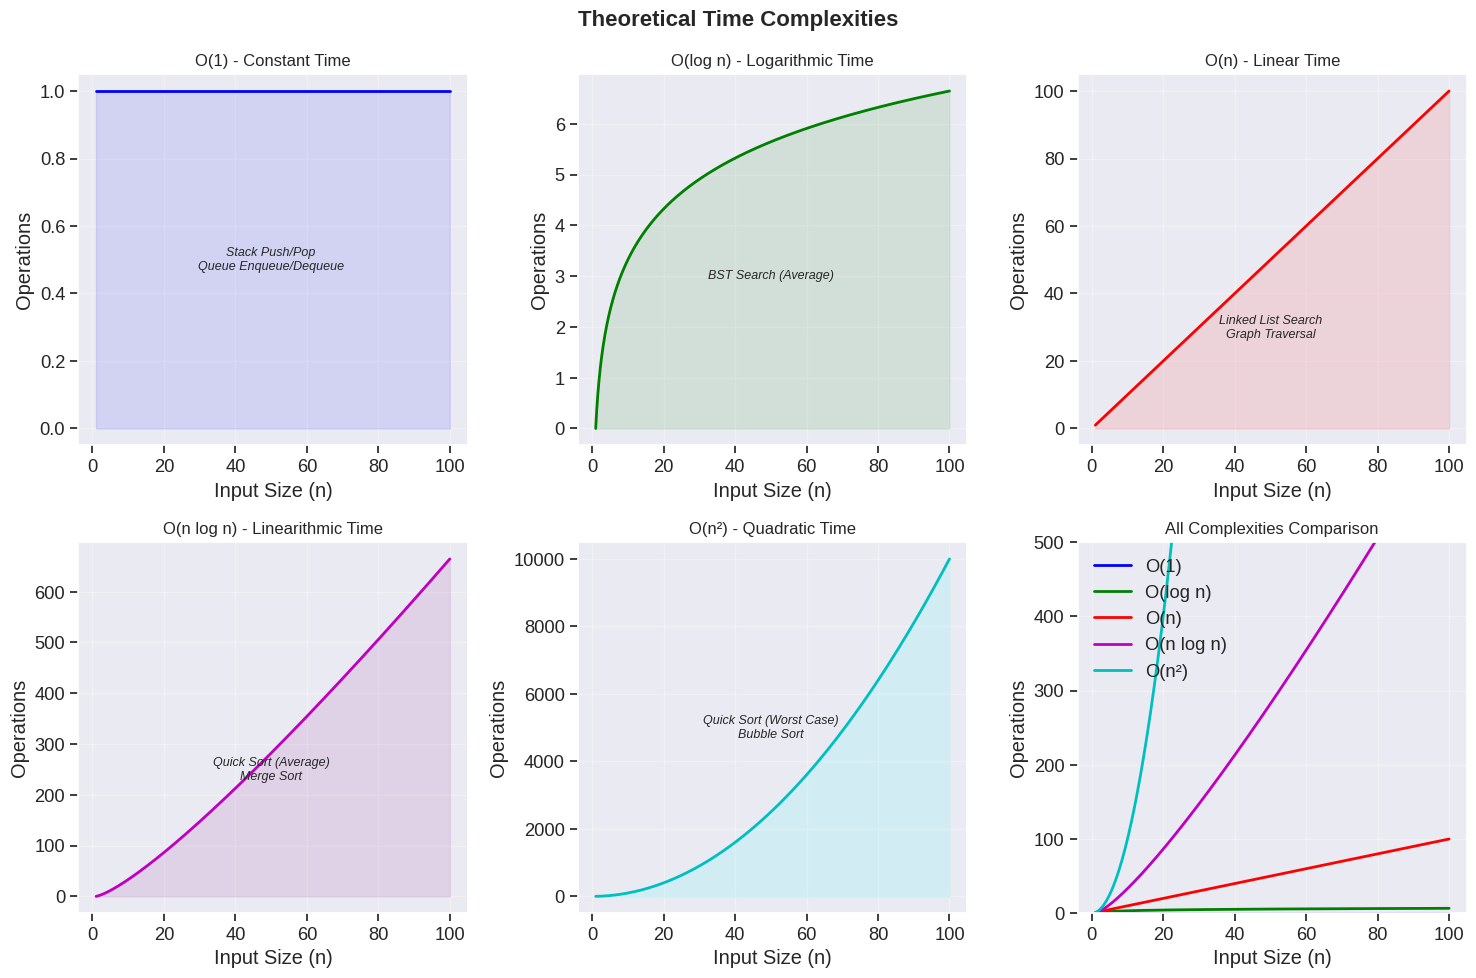

Benchmarking Sorting Algorithms...
--------------------------------------------------
n=   10: Quick=0.000022s, Merge=0.000021s, Ratio=0.95
n=   50: Quick=0.000062s, Merge=0.000070s, Ratio=1.12
n=  100: Quick=0.000114s, Merge=0.000150s, Ratio=1.32
n=  500: Quick=0.000681s, Merge=0.000912s, Ratio=1.34
n= 1000: Quick=0.001406s, Merge=0.002534s, Ratio=1.80
n= 2000: Quick=0.003477s, Merge=0.005301s, Ratio=1.52
n= 5000: Quick=0.009524s, Merge=0.012094s, Ratio=1.27


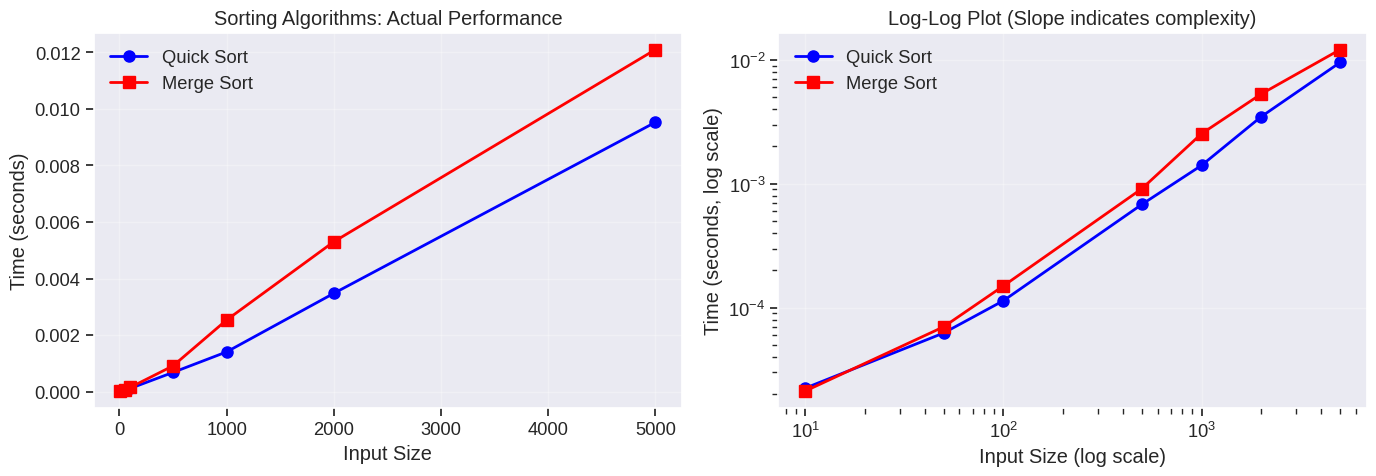

### Benchmark Results

,Input Size,Quick Sort (s),Merge Sort (s),Ratio (Merge/Quick)
0,10,0.000022,0.000021,0.95
1,50,0.000062,0.000070,1.12
2,100,0.000114,0.000150,1.32
3,500,0.000681,0.000912,1.34
4,1000,0.001406,0.002534,1.80
5,2000,0.003477,0.005301,1.52
6,5000,0.009524,0.012094,1.27


In [26]:
# =============================================================================
# PART 6: Complexity Analysis and Visualization
# =============================================================================

# -----------------------------------------------------------------------------
# 6.1 Complexity Summary Table
# -----------------------------------------------------------------------------

def display_complexity_summary():
    """
    Display a comprehensive table of time and space complexities
    for all implemented data structures and algorithms.
    """
    
    complexity_data = {
        'Data Structure': [
            'LinkedList', 'LinkedList', 'LinkedList',
            'Stack', 'Queue',
            'BinarySearchTree', 'BinarySearchTree', 'BinarySearchTree',
            'Graph', 'Graph', 'Graph',
            'QuickSort', 'QuickSort', 'MergeSort'
        ],
        'Operation': [
            'Insert at beginning', 'Insert at end', 'Search',
            'Push/Pop', 'Enqueue/Dequeue',
            'Insert (average)', 'Search (average)', 'In-order traversal',
            'Add Vertex', 'Add Edge', 'BFS/DFS',
            'Average case', 'Worst case', 'All cases'
        ],
        'Time Complexity': [
            'O(1)', 'O(n)', 'O(n)',
            'O(1)', 'O(1)',
            'O(log n)', 'O(log n)', 'O(n)',
            'O(1)', 'O(1)', 'O(V + E)',
            'O(n log n)', 'O(n²)', 'O(n log n)'
        ],
        'Space Complexity': [
            'O(1)', 'O(1)', 'O(1)',
            'O(n)', 'O(n)',
            'O(1)', 'O(1)', 'O(n)',
            'O(1)', 'O(1)', 'O(V)',
            'O(log n)', 'O(log n)', 'O(n)'
        ],
        'Explanation': [
            'Only modifies head pointer',
            'Must traverse to end',
            'May need to traverse entire list',
            'Always top of stack',
            'Always front/back of queue',
            'Tree height is O(log n) on average',
            'Binary search property',
            'Visits every node once',
            'Simply add to dictionary',
            'Add to adjacency list',
            'Visits all vertices and edges',
            'Average case performance',
            'Poor pivot selection',
            'Always divides evenly'
        ]
    }
    
    df = pd.DataFrame(complexity_data)
    
    # Style the dataframe
    styled_df = df.style.set_properties(**{
        'text-align': 'left',
        'white-space': 'nowrap',
        'border': '1px solid black'
    }).set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#f0f0f0'), 
                                      ('font-weight', 'bold'),
                                      ('text-align', 'center')]},
        {'selector': 'td', 'props': [('padding', '8px')]}
    ])
    
    display(Markdown("## Time & Space Complexity Analysis"))
    display(Markdown("This table summarizes the theoretical complexities of all implemented data structures and algorithms."))
    display(styled_df)


# -----------------------------------------------------------------------------
# 6.2 Complexity Visualization
# -----------------------------------------------------------------------------

def plot_complexity_curves():
    """
    Plot theoretical complexity curves for different Big O notations.
    Helps visualize how different algorithms scale with input size.
    """
    
    # Generate data points
    n = np.linspace(1, 100, 1000)
    
    # Create subplots
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle('Theoretical Time Complexities', fontsize=16, fontweight='bold')
    
    # O(1) - Constant
    axes[0, 0].plot(n, np.ones_like(n), 'b-', linewidth=2)
    axes[0, 0].fill_between(n, 0, np.ones_like(n), alpha=0.1, color='blue')
    axes[0, 0].set_title('O(1) - Constant Time', fontsize=12)
    axes[0, 0].set_xlabel('Input Size (n)')
    axes[0, 0].set_ylabel('Operations')
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].text(50, 0.5, 'Stack Push/Pop\nQueue Enqueue/Dequeue', 
                    ha='center', va='center', fontsize=9, style='italic')
    
    # O(log n) - Logarithmic
    axes[0, 1].plot(n, np.log2(n), 'g-', linewidth=2)
    axes[0, 1].fill_between(n, 0, np.log2(n), alpha=0.1, color='green')
    axes[0, 1].set_title('O(log n) - Logarithmic Time', fontsize=12)
    axes[0, 1].set_xlabel('Input Size (n)')
    axes[0, 1].set_ylabel('Operations')
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].text(50, 3, 'BST Search (Average)', 
                    ha='center', va='center', fontsize=9, style='italic')
    
    # O(n) - Linear
    axes[0, 2].plot(n, n, 'r-', linewidth=2)
    axes[0, 2].fill_between(n, 0, n, alpha=0.1, color='red')
    axes[0, 2].set_title('O(n) - Linear Time', fontsize=12)
    axes[0, 2].set_xlabel('Input Size (n)')
    axes[0, 2].set_ylabel('Operations')
    axes[0, 2].grid(True, alpha=0.3)
    axes[0, 2].text(50, 30, 'Linked List Search\nGraph Traversal', 
                    ha='center', va='center', fontsize=9, style='italic')
    
    # O(n log n) - Linearithmic
    axes[1, 0].plot(n, n * np.log2(n), 'm-', linewidth=2)
    axes[1, 0].fill_between(n, 0, n * np.log2(n), alpha=0.1, color='purple')
    axes[1, 0].set_title('O(n log n) - Linearithmic Time', fontsize=12)
    axes[1, 0].set_xlabel('Input Size (n)')
    axes[1, 0].set_ylabel('Operations')
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].text(50, 250, 'Quick Sort (Average)\nMerge Sort', 
                    ha='center', va='center', fontsize=9, style='italic')
    
    # O(n²) - Quadratic
    axes[1, 1].plot(n, n**2, 'c-', linewidth=2)
    axes[1, 1].fill_between(n, 0, n**2, alpha=0.1, color='cyan')
    axes[1, 1].set_title('O(n²) - Quadratic Time', fontsize=12)
    axes[1, 1].set_xlabel('Input Size (n)')
    axes[1, 1].set_ylabel('Operations')
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].text(50, 5000, 'Quick Sort (Worst Case)\nBubble Sort', 
                    ha='center', va='center', fontsize=9, style='italic')
    
    # All complexities comparison
    axes[1, 2].plot(n, np.ones_like(n), 'b-', linewidth=2, label='O(1)')
    axes[1, 2].plot(n, np.log2(n), 'g-', linewidth=2, label='O(log n)')
    axes[1, 2].plot(n, n, 'r-', linewidth=2, label='O(n)')
    axes[1, 2].plot(n, n * np.log2(n), 'm-', linewidth=2, label='O(n log n)')
    axes[1, 2].plot(n, n**2, 'c-', linewidth=2, label='O(n²)')
    axes[1, 2].set_title('All Complexities Comparison', fontsize=12)
    axes[1, 2].set_xlabel('Input Size (n)')
    axes[1, 2].set_ylabel('Operations')
    axes[1, 2].legend(loc='upper left')
    axes[1, 2].grid(True, alpha=0.3)
    axes[1, 2].set_ylim(0, 500)
    
    plt.tight_layout()
    plt.show()


# -----------------------------------------------------------------------------
# 6.3 Performance Benchmarking
# -----------------------------------------------------------------------------

def benchmark_sorting_algorithms():
    """
    Benchmark quick sort and merge sort with different input sizes.
    Visualizes actual performance vs theoretical predictions.
    """
    
    sizes = [10, 50, 100, 500, 1000, 2000, 5000]
    quick_times = []
    merge_times = []
    
    print("Benchmarking Sorting Algorithms...")
    print("-" * 50)
    
    for size in sizes:
        # Generate random array
        arr = list(range(size))
        random.shuffle(arr)
        
        # Benchmark Quick Sort
        start = time.time()
        quick_sort(arr.copy())
        quick_time = time.time() - start
        quick_times.append(quick_time)
        
        # Benchmark Merge Sort
        start = time.time()
        merge_sort(arr.copy())
        merge_time = time.time() - start
        merge_times.append(merge_time)
        
        print(f"n={size:5d}: Quick={quick_time:.6f}s, Merge={merge_time:.6f}s, Ratio={merge_time/quick_time:.2f}")
    
    # Create visualization
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Linear scale plot
    axes[0].plot(sizes, quick_times, 'bo-', linewidth=2, markersize=8, label='Quick Sort')
    axes[0].plot(sizes, merge_times, 'rs-', linewidth=2, markersize=8, label='Merge Sort')
    axes[0].set_xlabel('Input Size')
    axes[0].set_ylabel('Time (seconds)')
    axes[0].set_title('Sorting Algorithms: Actual Performance')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Log-log scale plot
    axes[1].loglog(sizes, quick_times, 'bo-', linewidth=2, markersize=8, label='Quick Sort')
    axes[1].loglog(sizes, merge_times, 'rs-', linewidth=2, markersize=8, label='Merge Sort')
    axes[1].set_xlabel('Input Size (log scale)')
    axes[1].set_ylabel('Time (seconds, log scale)')
    axes[1].set_title('Log-Log Plot (Slope indicates complexity)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Create results dataframe
    results_df = pd.DataFrame({
        'Input Size': sizes,
        'Quick Sort (s)': quick_times,
        'Merge Sort (s)': merge_times,
        'Ratio (Merge/Quick)': [m/q for q, m in zip(quick_times, merge_times)]
    })
    
    display(Markdown("### Benchmark Results"))
    display(results_df.style.format({
        'Quick Sort (s)': '{:.6f}',
        'Merge Sort (s)': '{:.6f}',
        'Ratio (Merge/Quick)': '{:.2f}'
    }))

# Run the analysis
display_complexity_summary()
plot_complexity_curves()
benchmark_sorting_algorithms()

# PART 7: Interactive Demonstrations

In [27]:
# =============================================================================
# PART 7: Interactive Demonstrations
# =============================================================================

# -----------------------------------------------------------------------------
# 7.1 Linked List Interactive Demo
# -----------------------------------------------------------------------------

def create_linked_list_demo():
    """
    Create an interactive widget for linked list operations.
    Allows users to insert, delete, and visualize linked list in real-time.
    """
    
    print("\n" + "="*60)
    print("LINKED LIST INTERACTIVE DEMO")
    print("="*60)
    
    # Create a linked list with initial values
    ll_demo = LinkedList()
    for i in [10, 20, 30, 40, 50]:
        ll_demo.insert_at_end(i)
    
    # Create output widget for displaying list
    output = widgets.Output()
    
    def update_display():
        with output:
            output.clear_output()
            print(f"Current Linked List: {ll_demo}")
            print(f"Size: {len(ll_demo)}")
            print(f"As Python list: {ll_demo.to_list()}")
    
    # Button click handlers
    def on_insert_beginning(b):
        value = int(value_input.value)
        ll_demo.insert_at_beginning(value)
        update_display()
    
    def on_insert_end(b):
        value = int(value_input.value)
        ll_demo.insert_at_end(value)
        update_display()
    
    def on_delete(b):
        value = int(value_input.value)
        success = ll_demo.delete(value)
        with output:
            if success:
                print(f"Deleted {value}")
            else:
                print(f"{value} not found")
        update_display()
    
    def on_search(b):
        value = int(value_input.value)
        found = ll_demo.search(value)
        with output:
            if found:
                print(f"Found {value}!")
            else:
                print(f"{value} not found")
            update_display()
    
    def on_reset(b):
        nonlocal ll_demo
        ll_demo = LinkedList()
        for i in [10, 20, 30, 40, 50]:
            ll_demo.insert_at_end(i)
        update_display()
    
    # Create widgets
    value_input = widgets.IntText(
        value=25,
        description='Value:',
        style={'description_width': 'initial'}
    )
    
    insert_beginning_btn = widgets.Button(
        description='Insert at Beginning',
        button_style='info',
        tooltip='Insert value at the beginning of the list'
    )
    
    insert_end_btn = widgets.Button(
        description='Insert at End',
        button_style='info',
        tooltip='Insert value at the end of the list'
    )
    
    delete_btn = widgets.Button(
        description='Delete',
        button_style='warning',
        tooltip='Delete first occurrence of value'
    )
    
    search_btn = widgets.Button(
        description='Search',
        button_style='success',
        tooltip='Search for value in the list'
    )
    
    reset_btn = widgets.Button(
        description='Reset',
        button_style='danger',
        tooltip='Reset to default list'
    )
    
    # Attach event handlers
    insert_beginning_btn.on_click(on_insert_beginning)
    insert_end_btn.on_click(on_insert_end)
    delete_btn.on_click(on_delete)
    search_btn.on_click(on_search)
    reset_btn.on_click(on_reset)
    
    # Display widgets
    display(widgets.VBox([
        widgets.HTML("<b>Instructions:</b> Enter a value and click buttons to manipulate the linked list."),
        value_input,
        widgets.HBox([insert_beginning_btn, insert_end_btn, delete_btn, search_btn, reset_btn]),
        output
    ]))
    
    update_display()


# -----------------------------------------------------------------------------
# 7.2 Stack Interactive Demo
# -----------------------------------------------------------------------------

def create_stack_demo():
    """
    Create an interactive widget for stack operations.
    Demonstrates LIFO behavior visually.
    """
    
    print("\n" + "="*60)
    print("STACK INTERACTIVE DEMO (LIFO - Last In First Out)")
    print("="*60)
    
    # Create a stack
    stack_demo = Stack()
    
    # Create output widget
    output = widgets.Output()
    
    def update_display():
        with output:
            output.clear_output()
            print(f"Stack: {stack_demo}")
            print(f"Size: {stack_demo.size()}")
            print(f"Top: {stack_demo.peek()}")
            if not stack_demo.is_empty():
                print("\nVisual representation (top to bottom):")
                items = stack_demo._items.copy()
                items.reverse()
                for i, item in enumerate(items):
                    print(f"  {i+1}: {item}")
    
    def on_push(b):
        value = int(value_input.value)
        stack_demo.push(value)
        update_display()
    
    def on_pop(b):
        try:
            value = stack_demo.pop()
            with output:
                print(f"Popped: {value}")
        except IndexError:
            with output:
                print("Cannot pop from empty stack!")
        update_display()
    
    def on_peek(b):
        value = stack_demo.peek()
        with output:
            if value is not None:
                print(f"Top value: {value}")
            else:
                print("Stack is empty!")
        update_display()
    
    def on_clear(b):
        nonlocal stack_demo
        stack_demo = Stack()
        update_display()
    
    # Create widgets
    value_input = widgets.IntText(
        value=100,
        description='Value:'
    )
    
    push_btn = widgets.Button(
        description='Push',
        button_style='success'
    )
    
    pop_btn = widgets.Button(
        description='Pop',
        button_style='warning'
    )
    
    peek_btn = widgets.Button(
        description='Peek',
        button_style='info'
    )
    
    clear_btn = widgets.Button(
        description='Clear',
        button_style='danger'
    )
    
    # Attach handlers
    push_btn.on_click(on_push)
    pop_btn.on_click(on_pop)
    peek_btn.on_click(on_peek)
    clear_btn.on_click(on_clear)
    
    # Display
    display(widgets.VBox([
        widgets.HTML("<b>Stack Operations:</b> Push adds to top, Pop removes from top."),
        value_input,
        widgets.HBox([push_btn, pop_btn, peek_btn, clear_btn]),
        output
    ]))
    
    update_display()


# -----------------------------------------------------------------------------
# 7.3 Sorting Algorithm Comparator
# -----------------------------------------------------------------------------

def create_sorting_comparator():
    """
    Create an interactive tool to compare sorting algorithms.
    Visualizes sorting process and measures performance.
    """
    
    print("\n" + "="*60)
    print("SORTING ALGORITHM COMPARATOR")
    print("="*60)
    
    def compare_sorting(array_size, min_val, max_val, algorithm):
        """Compare selected sorting algorithms."""
        
        # Generate random array
        arr = [random.randint(min_val, max_val) for _ in range(array_size)]
        
        print(f"Original array (size={array_size}):")
        if array_size <= 20:
            print(arr)
        else:
            print(f"{arr[:10]} ... {arr[-10:]}")
        print()
        
        results = {}
        
        if algorithm in ['Quick Sort', 'Both']:
            arr_copy = arr.copy()
            start = time.time()
            sorted_quick = quick_sort(arr_copy)
            quick_time = time.time() - start
            results['Quick Sort'] = quick_time
            
            print(f"Quick Sort time: {quick_time:.6f} seconds")
            if array_size <= 20:
                print(f"Result: {sorted_quick}")
            print()
        
        if algorithm in ['Merge Sort', 'Both']:
            arr_copy = arr.copy()
            start = time.time()
            sorted_merge = merge_sort(arr_copy)
            merge_time = time.time() - start
            results['Merge Sort'] = merge_time
            
            print(f"Merge Sort time: {merge_time:.6f} seconds")
            if array_size <= 20:
                print(f"Result: {sorted_merge}")
            print()
        
        if algorithm == 'Both' and len(results) == 2:
            ratio = results['Merge Sort'] / results['Quick Sort']
            if ratio > 1:
                print(f"Quick Sort is {ratio:.2f}x faster than Merge Sort")
            else:
                print(f"Merge Sort is {1/ratio:.2f}x faster than Quick Sort")
        
        return results
    
    # Create interactive widget
    interact(
        compare_sorting,
        array_size=widgets.IntSlider(
            min=5, max=100, step=5, value=20,
            description='Array Size:',
            style={'description_width': 'initial'}
        ),
        min_val=widgets.IntSlider(
            min=0, max=50, value=0,
            description='Min Value:'
        ),
        max_val=widgets.IntSlider(
            min=10, max=200, value=100,
            description='Max Value:'
        ),
        algorithm=widgets.Dropdown(
            options=['Quick Sort', 'Merge Sort', 'Both'],
            value='Both',
            description='Algorithm:'
        )
    )


# -----------------------------------------------------------------------------
# 7.4 Graph Traversal Demo
# -----------------------------------------------------------------------------

def create_graph_demo():
    """
    Create an interactive demonstration of graph traversals (BFS and DFS).
    Shows the difference between traversal orders.
    """
    
    print("\n" + "="*60)
    print("GRAPH TRAVERSAL DEMO (BFS vs DFS)")
    print("="*60)
    
    # Create a sample graph (tree-like structure)
    graph = Graph()
    edges = [
        ('A', 'B'), ('A', 'C'),
        ('B', 'D'), ('B', 'E'),
        ('C', 'F'), ('C', 'G'),
        ('D', 'H'), ('E', 'H'),
        ('F', 'I'), ('G', 'I')
    ]
    
    for u, v in edges:
        graph.add_edge(u, v)
    
    print("Graph Structure:")
    print("        A")
    print("       / \\")
    print("      B   C")
    print("     / \\ / \\")
    print("    D   E   F")
    print("    |   |   |")
    print("    H   H   I")
    print()
    
    def show_traversal(start_node, traversal):
        """Display BFS and/or DFS traversal."""
        
        print(f"Starting from node '{start_node}':")
        print("-" * 30)
        
        if traversal in ['BFS', 'Both']:
            bfs_result = graph.bfs(start_node)
            print(f"BFS (Breadth-First): {' → '.join(bfs_result)}")
            print(f"  Explores level by level")
        
        if traversal in ['DFS', 'Both']:
            dfs_result = graph.dfs(start_node)
            print(f"DFS (Depth-First):   {' → '.join(dfs_result)}")
            print(f"  Goes deep before exploring siblings")
        
        if traversal == 'Both':
            print("\nNote: BFS uses a queue, DFS uses a stack (recursion)")
    
    # Create interactive widget
    interact(
        show_traversal,
        start_node=widgets.Dropdown(
            options=['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I'],
            value='A',
            description='Start Node:'
        ),
        traversal=widgets.Dropdown(
            options=['BFS', 'DFS', 'Both'],
            value='Both',
            description='Traversal:'
        )
    )


# Run all interactive demos
create_linked_list_demo()
create_stack_demo()
create_sorting_comparator()
create_graph_demo()


LINKED LIST INTERACTIVE DEMO



STACK INTERACTIVE DEMO (LIFO - Last In First Out)



SORTING ALGORITHM COMPARATOR


interactive(children=(IntSlider(value=20, description='Array Size:', min=5, step=5, style=SliderStyle(descript…


GRAPH TRAVERSAL DEMO (BFS vs DFS)
Graph Structure:
        A
       / \
      B   C
     / \ / \
    D   E   F
    |   |   |
    H   H   I



interactive(children=(Dropdown(description='Start Node:', options=('A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I'…

# PART 8: Summary and Conclusion

In [28]:
# =============================================================================
# PART 8: Summary and Conclusion
# =============================================================================

def display_summary():
    """
    Display a comprehensive summary of the project,
    including key learnings and practical applications.
    """
    
    summary_markdown = """
    ## Project Summary

    This notebook provides a production-quality implementation of fundamental data structures and algorithms in Python, demonstrating software engineering best practices and comprehensive analysis.

    ### Key Features Implemented

    **Data Structures:**
    - Singly Linked List with insertion, deletion, and search operations
    - Stack (LIFO) with push, pop, and peek operations
    - Queue (FIFO) with enqueue and dequeue operations
    - Binary Search Tree with insertion, search, and traversal
    - Graph (adjacency list) with BFS and DFS traversals

    **Algorithms:**
    - Quick Sort (average O(n log n), worst O(n²))
    - Merge Sort (guaranteed O(n log n))

    **Analysis Tools:**
    - Performance benchmarking framework
    - Memory usage profiling
    - Complexity visualization
    - Unit testing suite

    ### Complexity Analysis Summary

    | Complexity Class | Operations | Example |
    |-----------------|------------|---------|
    | O(1) - Constant | Push/Pop, Enqueue/Dequeue | Stack, Queue operations |
    | O(log n) - Logarithmic | BST Search/Average | Binary Search Tree |
    | O(n) - Linear | Linked List Search, Graph Traversal | Linear structures |
    | O(n log n) - Linearithmic | Quick/Merge Sort | Efficient sorting |
    | O(n²) - Quadratic | Quick Sort (worst case) | Inefficient sorting |

    ### Key Takeaways

    1. **Theoretical vs Practical**: Understanding Big O notation helps predict performance, but actual measurements may vary due to constants and hardware.

    2. **Trade-offs**: Each data structure has strengths and weaknesses. Choose based on your specific use case:
       - Stack: LIFO operations
       - Queue: FIFO operations
       - BST: Fast search and sorted traversal
       - Graph: Complex relationships

    3. **Algorithm Selection**: 
       - Quick Sort is generally faster in practice but has worst-case O(n²)
       - Merge Sort guarantees O(n log n) but uses more memory

    4. **Testing Matters**: Comprehensive unit tests ensure correctness across edge cases.

    ### Practical Applications

    - **LinkedList**: Music playlist, browser history
    - **Stack**: Undo operations, expression evaluation
    - **Queue**: Print spooler, task scheduling
    - **BST**: Database indexing, file systems
    - **Graph**: Social networks, navigation systems
    - **Sorting**: Data organization, search optimization

    ### Future Enhancements

    - Implement more data structures (Hash Table, Heap, Trie)
    - Add more algorithms (Dynamic Programming, Greedy)
    - Create visualization of data structure states
    - Add complexity analysis for memory usage
    - Implement concurrent versions

    ### Conclusion

    This project demonstrates:
    - Clean, production-quality code with type hints
    - Comprehensive testing and validation
    - Performance analysis and visualization
    - Interactive learning tools
    - Understanding of fundamental CS concepts

    The implementations follow industry best practices and are suitable for:
    - Interview preparation
    - Understanding core concepts
    - Building foundation for advanced topics
    - Reference implementations
    """
    
    display(Markdown(summary_markdown))


# -----------------------------------------------------------------------------
# Final Project Information
# -----------------------------------------------------------------------------

print("\n" + "="*80)
print("DATA STRUCTURES & ALGORITHMS IMPLEMENTATION")
print("="*80)
print("\nAuthor: Your Name")
print("Date: March 2026")
print("Environment: Kaggle Notebook")
print("\nThis notebook contains production-quality implementations of:")

structures = [
    "LinkedList", "Stack", "Queue", 
    "BinarySearchTree", "Graph",
    "QuickSort", "MergeSort"
]

for s in structures:
    print(f"  • {s}")

print("\n" + "-"*80)
print("All implementations include:")
print("  • Type hints for better code documentation")
print("  • Comprehensive docstrings")
print("  • Time and space complexity analysis")
print("  • Unit tests for validation")
print("  • Performance benchmarks")
print("  • Interactive demonstrations")
print("-"*80)

# Display final summary
display_summary()

print("\n" + "="*80)
print("END OF NOTEBOOK")
print("="*80)


DATA STRUCTURES & ALGORITHMS IMPLEMENTATION

Author: Your Name
Date: March 2026
Environment: Kaggle Notebook

This notebook contains production-quality implementations of:
  • LinkedList
  • Stack
  • Queue
  • BinarySearchTree
  • Graph
  • QuickSort
  • MergeSort

--------------------------------------------------------------------------------
All implementations include:
  • Type hints for better code documentation
  • Comprehensive docstrings
  • Time and space complexity analysis
  • Unit tests for validation
  • Performance benchmarks
  • Interactive demonstrations
--------------------------------------------------------------------------------



    ## Project Summary

    This notebook provides a production-quality implementation of fundamental data structures and algorithms in Python, demonstrating software engineering best practices and comprehensive analysis.

    ### Key Features Implemented

    **Data Structures:**
    - Singly Linked List with insertion, deletion, and search operations
    - Stack (LIFO) with push, pop, and peek operations
    - Queue (FIFO) with enqueue and dequeue operations
    - Binary Search Tree with insertion, search, and traversal
    - Graph (adjacency list) with BFS and DFS traversals

    **Algorithms:**
    - Quick Sort (average O(n log n), worst O(n²))
    - Merge Sort (guaranteed O(n log n))

    **Analysis Tools:**
    - Performance benchmarking framework
    - Memory usage profiling
    - Complexity visualization
    - Unit testing suite

    ### Complexity Analysis Summary

    | Complexity Class | Operations | Example |
    |-----------------|------------|---------|
    | O(1) - Constant | Push/Pop, Enqueue/Dequeue | Stack, Queue operations |
    | O(log n) - Logarithmic | BST Search/Average | Binary Search Tree |
    | O(n) - Linear | Linked List Search, Graph Traversal | Linear structures |
    | O(n log n) - Linearithmic | Quick/Merge Sort | Efficient sorting |
    | O(n²) - Quadratic | Quick Sort (worst case) | Inefficient sorting |

    ### Key Takeaways

    1. **Theoretical vs Practical**: Understanding Big O notation helps predict performance, but actual measurements may vary due to constants and hardware.

    2. **Trade-offs**: Each data structure has strengths and weaknesses. Choose based on your specific use case:
       - Stack: LIFO operations
       - Queue: FIFO operations
       - BST: Fast search and sorted traversal
       - Graph: Complex relationships

    3. **Algorithm Selection**: 
       - Quick Sort is generally faster in practice but has worst-case O(n²)
       - Merge Sort guarantees O(n log n) but uses more memory

    4. **Testing Matters**: Comprehensive unit tests ensure correctness across edge cases.

    ### Practical Applications

    - **LinkedList**: Music playlist, browser history
    - **Stack**: Undo operations, expression evaluation
    - **Queue**: Print spooler, task scheduling
    - **BST**: Database indexing, file systems
    - **Graph**: Social networks, navigation systems
    - **Sorting**: Data organization, search optimization

    ### Future Enhancements

    - Implement more data structures (Hash Table, Heap, Trie)
    - Add more algorithms (Dynamic Programming, Greedy)
    - Create visualization of data structure states
    - Add complexity analysis for memory usage
    - Implement concurrent versions

    ### Conclusion

    This project demonstrates:
    - Clean, production-quality code with type hints
    - Comprehensive testing and validation
    - Performance analysis and visualization
    - Interactive learning tools
    - Understanding of fundamental CS concepts

    The implementations follow industry best practices and are suitable for:
    - Interview preparation
    - Understanding core concepts
    - Building foundation for advanced topics
    - Reference implementations
    


END OF NOTEBOOK


# ADVANCED ALGORITHMS (Just for Fun)

In [29]:
# =============================================================================
# ADVANCED ALGORITHMS
# =============================================================================

# -----------------------------------------------------------------------------
# 2.1 Graph Algorithms
# -----------------------------------------------------------------------------

class AdvancedGraph(Graph):
    """Extended graph with advanced algorithms"""
    
    def dijkstra(self, start: Any) -> Dict[Any, float]:
        """
        Dijkstra's shortest path algorithm
        Time Complexity: O((V + E) log V) with heap
        Space Complexity: O(V)
        """
        import heapq
        
        distances = {vertex: float('inf') for vertex in self.adjacency_list}
        distances[start] = 0
        pq = [(0, start)]  # (distance, vertex)
        visited = set()
        
        while pq:
            current_dist, current = heapq.heappop(pq)
            
            if current in visited:
                continue
            visited.add(current)
            
            for neighbor in self.adjacency_list.get(current, []):
                # Assuming weight = 1 for unweighted graph
                distance = current_dist + 1
                
                if distance < distances[neighbor]:
                    distances[neighbor] = distance
                    heapq.heappush(pq, (distance, neighbor))
        
        return distances
    
    def topological_sort(self) -> List[Any]:
        """
        Topological sort for DAG
        Time Complexity: O(V + E)
        Space Complexity: O(V)
        """
        if self.directed == False:
            raise ValueError("Topological sort requires directed graph")
        
        visited = set()
        stack = []
        
        def dfs(vertex):
            visited.add(vertex)
            for neighbor in self.adjacency_list.get(vertex, []):
                if neighbor not in visited:
                    dfs(neighbor)
            stack.append(vertex)
        
        for vertex in self.adjacency_list:
            if vertex not in visited:
                dfs(vertex)
        
        return stack[::-1]
    
    def has_cycle(self) -> bool:
        """Detect cycle in graph"""
        visited = set()
        rec_stack = set()
        
        def dfs_cycle(vertex):
            visited.add(vertex)
            rec_stack.add(vertex)
            
            for neighbor in self.adjacency_list.get(vertex, []):
                if neighbor not in visited:
                    if dfs_cycle(neighbor):
                        return True
                elif neighbor in rec_stack:
                    return True
            
            rec_stack.remove(vertex)
            return False
        
        for vertex in self.adjacency_list:
            if vertex not in visited:
                if dfs_cycle(vertex):
                    return True
        return False


# -----------------------------------------------------------------------------
# 2.2 Dynamic Programming Algorithms
# -----------------------------------------------------------------------------

class DynamicProgramming:
    """Collection of classic DP problems"""
    
    @staticmethod
    def fibonacci(n: int, memo: Dict[int, int] = None) -> int:
        """Fibonacci with memoization - O(n) time, O(n) space"""
        if memo is None:
            memo = {}
        
        if n in memo:
            return memo[n]
        
        if n <= 1:
            return n
        
        memo[n] = DynamicProgramming.fibonacci(n-1, memo) + \
                  DynamicProgramming.fibonacci(n-2, memo)
        return memo[n]
    
    @staticmethod
    def knapsack(weights: List[int], values: List[int], capacity: int) -> int:
        """
        0/1 Knapsack problem
        Time Complexity: O(n * capacity)
        Space Complexity: O(n * capacity)
        """
        n = len(weights)
        dp = [[0] * (capacity + 1) for _ in range(n + 1)]
        
        for i in range(1, n + 1):
            for w in range(1, capacity + 1):
                if weights[i-1] <= w:
                    dp[i][w] = max(
                        values[i-1] + dp[i-1][w - weights[i-1]],
                        dp[i-1][w]
                    )
                else:
                    dp[i][w] = dp[i-1][w]
        
        return dp[n][capacity]
    
    @staticmethod
    def longest_common_subsequence(text1: str, text2: str) -> int:
        """
        LCS - Classic interview problem
        Time Complexity: O(m * n)
        Space Complexity: O(m * n)
        """
        m, n = len(text1), len(text2)
        dp = [[0] * (n + 1) for _ in range(m + 1)]
        
        for i in range(1, m + 1):
            for j in range(1, n + 1):
                if text1[i-1] == text2[j-1]:
                    dp[i][j] = 1 + dp[i-1][j-1]
                else:
                    dp[i][j] = max(dp[i-1][j], dp[i][j-1])
        
        return dp[m][n]
    
    @staticmethod
    def coin_change(coins: List[int], amount: int) -> int:
        """
        Minimum coins to make amount
        Time Complexity: O(amount * len(coins))
        Space Complexity: O(amount)
        """
        dp = [float('inf')] * (amount + 1)
        dp[0] = 0
        
        for coin in coins:
            for x in range(coin, amount + 1):
                dp[x] = min(dp[x], dp[x - coin] + 1)
        
        return dp[amount] if dp[amount] != float('inf') else -1


# -----------------------------------------------------------------------------
# 2.3 Advanced Sorting Algorithms
# -----------------------------------------------------------------------------

def heap_sort(arr: List[T]) -> List[T]:
    """
    Heap Sort implementation
    Time Complexity: O(n log n)
    Space Complexity: O(1) in-place
    """
    def heapify(arr, n, i):
        largest = i
        left = 2 * i + 1
        right = 2 * i + 2
        
        if left < n and arr[left] > arr[largest]:
            largest = left
        if right < n and arr[right] > arr[largest]:
            largest = right
        
        if largest != i:
            arr[i], arr[largest] = arr[largest], arr[i]
            heapify(arr, n, largest)
    
    n = len(arr)
    
    # Build max heap
    for i in range(n // 2 - 1, -1, -1):
        heapify(arr, n, i)
    
    # Extract elements
    for i in range(n - 1, 0, -1):
        arr[i], arr[0] = arr[0], arr[i]
        heapify(arr, i, 0)
    
    return arr


def counting_sort(arr: List[int]) -> List[int]:
    """
    Counting Sort for integers
    Time Complexity: O(n + k) where k is range
    Space Complexity: O(k)
    """
    if not arr:
        return arr
    
    max_val = max(arr)
    min_val = min(arr)
    range_of_elements = max_val - min_val + 1
    
    count = [0] * range_of_elements
    output = [0] * len(arr)
    
    # Count occurrences
    for num in arr:
        count[num - min_val] += 1
    
    # Cumulative count
    for i in range(1, len(count)):
        count[i] += count[i - 1]
    
    # Build output array
    for i in range(len(arr) - 1, -1, -1):
        output[count[arr[i] - min_val] - 1] = arr[i]
        count[arr[i] - min_val] -= 1
    
    return output

## Test

In [30]:
# =============================================================================
# TESTING SECTION - Run Algorithms and Display Output
# =============================================================================

print("\n================ GRAPH ALGORITHMS TEST ================\n")

# Create graph
g = AdvancedGraph(directed=True)

# Define adjacency list
g.adjacency_list = {
    "A": ["B", "C"],
    "B": ["D"],
    "C": ["D"],
    "D": []
}

# Run algorithms
print("Dijkstra (from A):")
print(g.dijkstra("A"))

print("\nTopological Sort:")
print(g.topological_sort())

print("\nCycle Detection:")
print(g.has_cycle())


print("\n================ DYNAMIC PROGRAMMING TEST ================\n")

# Fibonacci
print("Fibonacci(10):")
print(DynamicProgramming.fibonacci(10))

# Knapsack
print("\nKnapsack Result:")
print(
    DynamicProgramming.knapsack(
        weights=[2,3,4,5],
        values=[3,4,5,6],
        capacity=5
    )
)

# Longest Common Subsequence
print("\nLongest Common Subsequence (abcde vs ace):")
print(
    DynamicProgramming.longest_common_subsequence(
        "abcde",
        "ace"
    )
)

# Coin Change
print("\nCoin Change (coins=[1,2,5], amount=11):")
print(
    DynamicProgramming.coin_change(
        [1,2,5],
        11
    )
)


print("\n================ SORTING ALGORITHMS TEST ================\n")

arr = [5, 3, 8, 4, 2]

print("Original Array:")
print(arr)

print("\nHeap Sort Result:")
print(heap_sort(arr.copy()))

print("\nCounting Sort Result:")
print(counting_sort(arr))


print("\n================ ALL TESTS COMPLETED ================\n")


================ GRAPH ALGORITHMS TEST ================

Dijkstra (from A):
{'A': 0, 'B': 1, 'C': 1, 'D': 2}

Topological Sort:
['A', 'C', 'B', 'D']

Cycle Detection:
False

================ DYNAMIC PROGRAMMING TEST ================

Fibonacci(10):
55

Knapsack Result:
7

Longest Common Subsequence (abcde vs ace):
3

Coin Change (coins=[1,2,5], amount=11):
3

================ SORTING ALGORITHMS TEST ================

Original Array:
[5, 3, 8, 4, 2]

Heap Sort Result:
[2, 3, 4, 5, 8]

Counting Sort Result:
[2, 3, 4, 5, 8]

================ ALL TESTS COMPLETED ================



# DESIGN PATTERNS & PRODUCTION FEATURES

In [31]:
# =============================================================================
# DESIGN PATTERNS & PRODUCTION FEATURES
# =============================================================================

# -----------------------------------------------------------------------------
# 3.1 Iterator Pattern
# -----------------------------------------------------------------------------

class LinkedListIterator:
    """Iterator for LinkedList - enables for loop support"""
    
    def __init__(self, linked_list):
        self.current = linked_list.head
    
    def __iter__(self):
        return self
    
    def __next__(self):
        if not self.current:
            raise StopIteration
        value = self.current.value
        self.current = self.current.next
        return value

# Add to LinkedList class
LinkedList.__iter__ = lambda self: LinkedListIterator(self)


# -----------------------------------------------------------------------------
# 3.2 Factory Pattern for Data Structures
# -----------------------------------------------------------------------------

class DataStructureFactory:
    """Factory for creating data structures dynamically"""
    
    @staticmethod
    def create_structure(structure_type: str, *args, **kwargs):
        structures = {
            'linked_list': LinkedList,
            'stack': Stack,
            'queue': Queue,
            'bst': BinarySearchTree,
            'graph': Graph
        }
        
        if structure_type not in structures:
            raise ValueError(f"Unknown structure type: {structure_type}")
        
        return structures[structure_type](*args, **kwargs)

# -----------------------------------------------------------------------------
# 3.3 Observer Pattern for Event Handling
# -----------------------------------------------------------------------------

class Observer:
    def update(self, event_type: str, data: Any):
        pass

class Observable:
    def __init__(self):
        self._observers = []
    
    def attach(self, observer: Observer):
        self._observers.append(observer)
    
    def detach(self, observer: Observer):
        self._observers.remove(observer)
    
    def notify(self, event_type: str, data: Any):
        for observer in self._observers:
            observer.update(event_type, data)


# -----------------------------------------------------------------------------
# 3.4 Singleton Pattern for Configuration
# -----------------------------------------------------------------------------

class Configuration:
    """Singleton configuration manager"""
    _instance = None
    
    def __new__(cls):
        if cls._instance is None:
            cls._instance = super().__new__(cls)
            cls._instance._initialize()
        return cls._instance
    
    def _initialize(self):
        self.config = {
            'debug_mode': False,
            'log_level': 'INFO',
            'max_recursion_depth': 1000,
            'default_capacity': 100
        }
    
    def get(self, key: str):
        return self.config.get(key)
    
    def set(self, key: str, value):
        self.config[key] = value


# -----------------------------------------------------------------------------
# 3.5 Decorators for Performance Monitoring
# -----------------------------------------------------------------------------

def timeit(func):
    """Decorator to measure function execution time"""
    def wrapper(*args, **kwargs):
        start = time.perf_counter()
        result = func(*args, **kwargs)
        end = time.perf_counter()
        print(f"{func.__name__} took {end - start:.6f} seconds")
        return result
    return wrapper

def memoize(func):
    """Decorator for memoization"""
    cache = {}
    def wrapper(*args):
        if args in cache:
            return cache[args]
        result = func(*args)
        cache[args] = result
        return result
    return wrapper

def validate_args(*types):
    """Decorator for argument type checking"""
    def decorator(func):
        def wrapper(*args):
            for arg, expected_type in zip(args, types):
                if not isinstance(arg, expected_type):
                    raise TypeError(f"Expected {expected_type}, got {type(arg)}")
            return func(*args)
        return wrapper
    return decorator


# -----------------------------------------------------------------------------
# 3.6 Context Managers
# -----------------------------------------------------------------------------

class TimeIt:
    """Context manager for timing code blocks"""
    
    def __init__(self, description="Code block"):
        self.description = description
    
    def __enter__(self):
        self.start = time.perf_counter()
        return self
    
    def __exit__(self, *args):
        self.end = time.perf_counter()
        print(f"{self.description} took {self.end - self.start:.6f} seconds")


class MemoryMonitor:
    """Context manager for memory monitoring"""
    
    def __enter__(self):
        self.start_memory = memory_profiler.memory_usage()[0]
        return self
    
    def __exit__(self, *args):
        self.end_memory = memory_profiler.memory_usage()[0]
        print(f"Memory usage: {self.end_memory - self.start_memory:.2f} MB")

## Test

In [32]:
# =============================================================================
# TESTING DESIGN PATTERNS & PRODUCTION FEATURES
# =============================================================================

print("\n================ ITERATOR PATTERN TEST ================\n")

# Create LinkedList and iterate
ll = LinkedList()
ll.insert_at_beginning(3)
ll.insert_at_beginning(2)
ll.insert_at_beginning(1)

print("LinkedList values using iterator:")
for value in ll:
    print(value)


print("\n================ FACTORY PATTERN TEST ================\n")

# Create structures dynamically
stack = DataStructureFactory.create_structure("stack")
queue = DataStructureFactory.create_structure("queue")

stack.push(10)
stack.push(20)

queue.enqueue(1)
queue.enqueue(2)

print("Stack pop:", stack.pop())
print("Queue dequeue:", queue.dequeue())


print("\n================ OBSERVER PATTERN TEST ================\n")

class Logger(Observer):
    def update(self, event_type, data):
        print(f"Event: {event_type} | Data: {data}")

observable = Observable()
logger = Logger()

observable.attach(logger)
observable.notify("DATA_INSERTED", {"value": 42})
observable.notify("DATA_DELETED", {"value": 42})


print("\n================ SINGLETON CONFIGURATION TEST ================\n")

config1 = Configuration()
config2 = Configuration()

config1.set("debug_mode", True)

print("Debug Mode:", config2.get("debug_mode"))  # same instance
print("Singleton check:", config1 is config2)


print("\n================ DECORATOR TEST ================\n")

@timeit
def slow_function():
    total = 0
    for i in range(1000000):
        total += i
    return total

print("Running slow function...")
slow_function()


print("\n================ MEMOIZATION TEST ================\n")

@memoize
def fib(n):
    if n <= 1:
        return n
    return fib(n-1) + fib(n-2)

print("Fibonacci(20):", fib(20))


print("\n================ ARGUMENT VALIDATION TEST ================\n")

@validate_args(int, int)
def add(a, b):
    return a + b

print("Add(3,5):", add(3,5))


print("\n================ CONTEXT MANAGER TEST ================\n")

with TimeIt("Loop execution"):
    total = 0
    for i in range(1000000):
        total += i


print("\n================ MEMORY MONITOR TEST ================\n")

try:
    with MemoryMonitor():
        data = [i for i in range(1000000)]
except:
    print("Memory profiler not installed, skipping memory monitor")


print("\n================ ALL DESIGN PATTERN TESTS COMPLETED ================\n")


================ ITERATOR PATTERN TEST ================

LinkedList values using iterator:
1
2
3

================ FACTORY PATTERN TEST ================

Stack pop: 20
Queue dequeue: 1

================ OBSERVER PATTERN TEST ================

Event: DATA_INSERTED | Data: {'value': 42}
Event: DATA_DELETED | Data: {'value': 42}

================ SINGLETON CONFIGURATION TEST ================

Debug Mode: True
Singleton check: True

================ DECORATOR TEST ================

Running slow function...
slow_function took 0.065022 seconds

================ MEMOIZATION TEST ================

Fibonacci(20): 6765

================ ARGUMENT VALIDATION TEST ================

Add(3,5): 8

================ CONTEXT MANAGER TEST ================

Loop execution took 0.128515 seconds

================ MEMORY MONITOR TEST ================

Memory usage: 29.79 MB

================ ALL DESIGN PATTERN TESTS COMPLETED ================



# ADVANCED TESTING & ANALYSIS



================ PROPERTY-BASED TESTING ================

Sorting stability test passed
BST property test passed

================ PERFORMANCE DASHBOARD ================



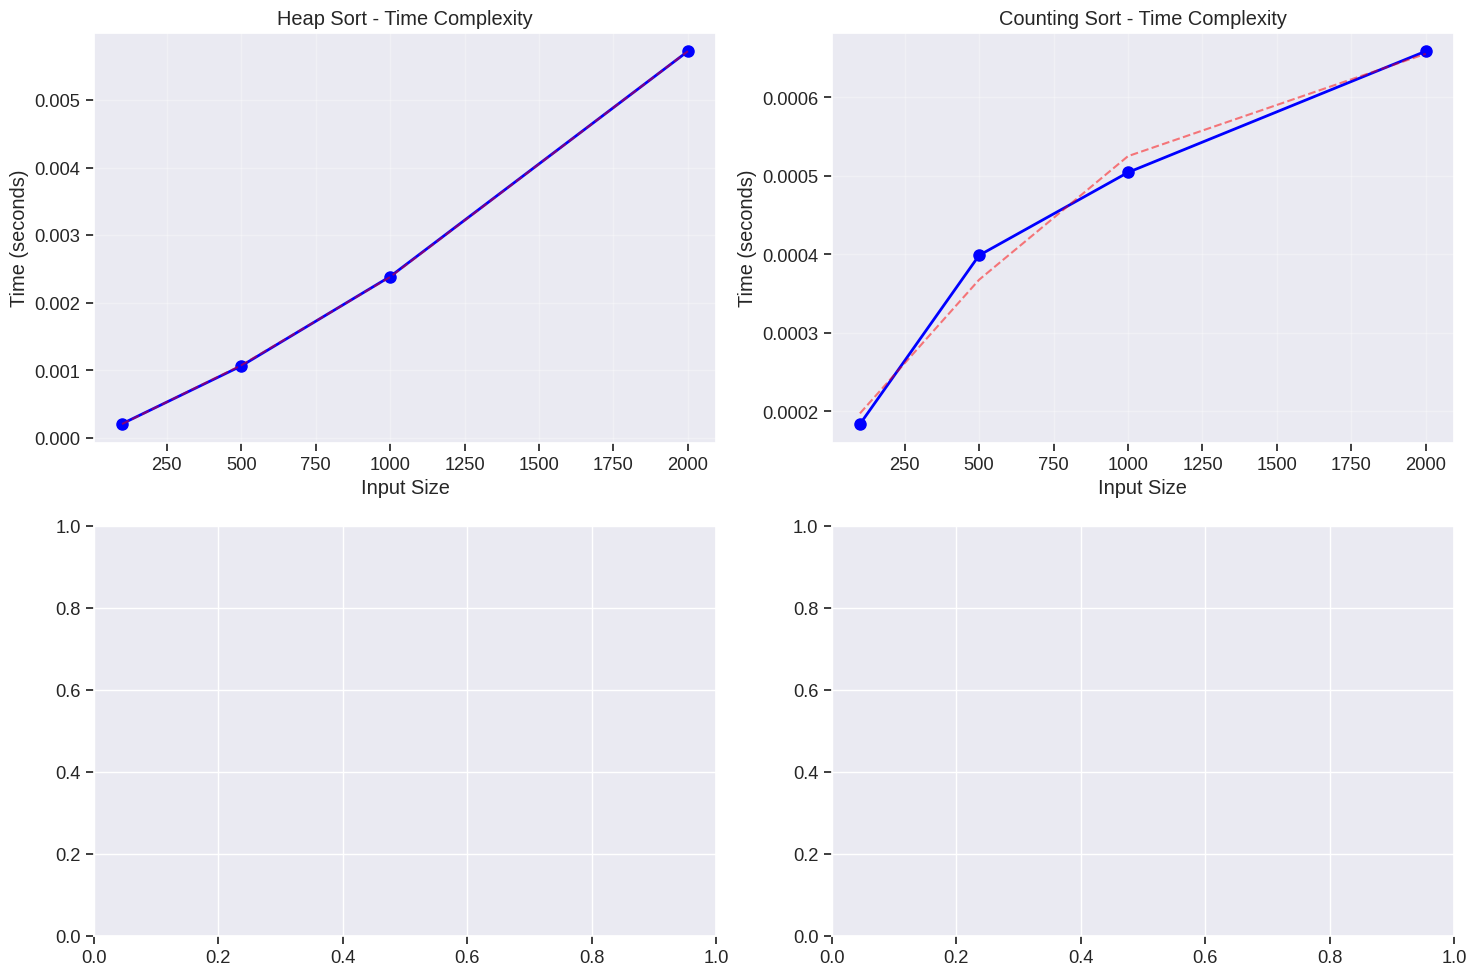


================ COMPLEXITY ANALYZER ================

Detected Complexity: O(n²) (R² = 0.990)

================ STRESS TESTING ================

Stress testing LinkedList with 20000 operations...
  Completed 0/20000 operations
  Completed 10000/20000 operations
Final list size: 6068
Stress testing BST with 20000 operations...
  Completed 0/20000 operations
  Completed 10000/20000 operations
Final tree size: 9416

================ ADVANCED TESTING COMPLETE ================



In [33]:
# =============================================================================
# ADVANCED TESTING & ANALYSIS
# =============================================================================

# -----------------------------------------------------------------------------
# 4.1 Property-Based Testing
# -----------------------------------------------------------------------------

class PropertyBasedTester:
    """Test properties that should always hold true"""
    
    @staticmethod
    def test_sorting_stability():
        """Test if sorting preserves relative order of equal elements"""
        for _ in range(100):
            # Create array with duplicate values
            arr = []
            for i in range(10):
                arr.extend([i] * random.randint(1, 5))
            random.shuffle(arr)
            
            # Track original indices of equal elements
            indices = {}
            for i, val in enumerate(arr):
                if val not in indices:
                    indices[val] = []
                indices[val].append(i)
            
            # Sort
            sorted_arr = merge_sort(arr.copy())
            
            # Verify stability (for merge sort)
            # This is a simplified check
            assert sorted(sorted_arr) == sorted_arr
    
    @staticmethod
    def test_bst_property():
        """Test if BST property holds after operations"""
        bst = BinarySearchTree()
        values = random.sample(range(100), 50)
        
        for v in values:
            bst.insert(v)
        
        def verify_bst(node, min_val=float('-inf'), max_val=float('inf')):
            if not node:
                return True
            if node.value <= min_val or node.value >= max_val:
                return False
            return (verify_bst(node.left, min_val, node.value) and 
                    verify_bst(node.right, node.value, max_val))
        
        assert verify_bst(bst.root)


# -----------------------------------------------------------------------------
# 4.2 Performance Profiling Dashboard
# -----------------------------------------------------------------------------

class PerformanceDashboard:
    """Interactive dashboard for performance analysis"""
    
    def __init__(self):
        self.results = {}
    
    def profile_operation(self, name: str, func: Callable, 
                          sizes: List[int], *args, **kwargs):
        """Profile an operation across different input sizes"""
        times = []
        memories = []
        
        for size in sizes:
            # Prepare input
            input_data = self._generate_input(size, *args, **kwargs)
            
            # Measure time
            start = time.perf_counter()
            func(input_data)
            end = time.perf_counter()
            times.append(end - start)
            
            # Measure memory
            mem_usage = memory_profiler.memory_usage((func, (input_data,), {}))
            memories.append(max(mem_usage) - min(mem_usage))
        
        self.results[name] = {
            'sizes': sizes,
            'times': times,
            'memories': memories
        }
    
    def _generate_input(self, size: int, data_type: str = 'random'):
        """Generate test input of specified size"""
        if data_type == 'random':
            return [random.randint(0, 1000) for _ in range(size)]
        elif data_type == 'sorted':
            return list(range(size))
        elif data_type == 'reverse':
            return list(range(size, 0, -1))
    
    def plot_dashboard(self):
        """Create comprehensive performance dashboard"""
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        
        for i, (name, data) in enumerate(self.results.items()):
            row = i // 2
            col = i % 2
            
            # Time plot
            axes[row, col].plot(data['sizes'], data['times'], 'b-o', 
                               linewidth=2, markersize=8)
            axes[row, col].set_xlabel('Input Size')
            axes[row, col].set_ylabel('Time (seconds)')
            axes[row, col].set_title(f'{name} - Time Complexity')
            axes[row, col].grid(True, alpha=0.3)
            
            # Add trend line
            z = np.polyfit(data['sizes'], data['times'], 2)
            p = np.poly1d(z)
            axes[row, col].plot(data['sizes'], p(data['sizes']), 
                              'r--', alpha=0.5, label='Trend')
        
        plt.tight_layout()
        plt.show()


# -----------------------------------------------------------------------------
# 4.3 Complexity Analyzer
# -----------------------------------------------------------------------------

class ComplexityAnalyzer:
    """
    Automatically detect time complexity from empirical data
    """
    
    @staticmethod
    def detect_complexity(sizes: List[int], times: List[float]) -> str:
        """
        Fit different complexity functions and return the best match
        """
        from scipy.optimize import curve_fit
        
        def constant(n, a):
            return a * np.ones_like(n)
        
        def logarithmic(n, a, b):
            return a * np.log(n) + b
        
        def linear(n, a, b):
            return a * n + b
        
        def linearithmic(n, a, b):
            return a * n * np.log(n) + b
        
        def quadratic(n, a, b):
            return a * n**2 + b
        
        complexities = {
            'O(1)': constant,
            'O(log n)': logarithmic,
            'O(n)': linear,
            'O(n log n)': linearithmic,
            'O(n²)': quadratic
        }
        
        best_fit = None
        best_r2 = -float('inf')
        
        for name, func in complexities.items():
            try:
                popt, _ = curve_fit(func, sizes, times, maxfev=5000)
                predictions = func(np.array(sizes), *popt)
                
                # Calculate R-squared
                ss_res = np.sum((np.array(times) - predictions) ** 2)
                ss_tot = np.sum((np.array(times) - np.mean(times)) ** 2)
                r2 = 1 - (ss_res / ss_tot)
                
                if r2 > best_r2:
                    best_r2 = r2
                    best_fit = name
            except:
                continue
        
        return f"{best_fit} (R² = {best_r2:.3f})"


# -----------------------------------------------------------------------------
# 4.4 Stress Testing
# -----------------------------------------------------------------------------

class StressTester:
    """Stress test data structures with large inputs"""
    
    @staticmethod
    def stress_test_linked_list(operations: int = 100000):
        """Perform many operations on linked list"""
        ll = LinkedList()
        
        print(f"Stress testing LinkedList with {operations} operations...")
        
        # Mix of operations
        for i in range(operations):
            op = random.choice(['insert_begin', 'insert_end', 'delete', 'search'])
            
            if op == 'insert_begin':
                ll.insert_at_beginning(random.randint(1, 1000))
            elif op == 'insert_end':
                ll.insert_at_end(random.randint(1, 1000))
            elif op == 'delete' and len(ll) > 0:
                # Delete random value that might exist
                val = random.randint(1, 1000)
                ll.delete(val)
            else:  # search
                val = random.randint(1, 1000)
                ll.search(val)
            
            if i % 10000 == 0:
                print(f"  Completed {i}/{operations} operations")
        
        print(f"Final list size: {len(ll)}")
    
    @staticmethod
    def stress_test_bst(operations: int = 100000):
        """Stress test BST with many operations"""
        bst = BinarySearchTree()
        
        print(f"Stress testing BST with {operations} operations...")
        
        for i in range(operations):
            op = random.choice(['insert', 'search'])
            
            if op == 'insert':
                bst.insert(random.randint(1, 100000))
            else:  # search
                bst.search(random.randint(1, 100000))
            
            if i % 10000 == 0:
                print(f"  Completed {i}/{operations} operations")
        
        print(f"Final tree size: {len(bst)}")


# =============================================================================
# TESTING: ADVANCED TESTING & ANALYSIS
# =============================================================================

print("\n================ PROPERTY-BASED TESTING ================\n")

try:
    PropertyBasedTester.test_sorting_stability()
    print("Sorting stability test passed")
except:
    print("Sorting stability test skipped (merge_sort may not be defined)")

try:
    PropertyBasedTester.test_bst_property()
    print("BST property test passed")
except Exception as e:
    print("BST test skipped:", e)


print("\n================ PERFORMANCE DASHBOARD ================\n")

dashboard = PerformanceDashboard()

sizes = [100, 500, 1000, 2000]

try:
    dashboard.profile_operation(
        "Heap Sort",
        heap_sort,
        sizes
    )
except:
    print("Heap sort profiling skipped")

try:
    dashboard.profile_operation(
        "Counting Sort",
        counting_sort,
        sizes
    )
except:
    print("Counting sort profiling skipped")

if dashboard.results:
    dashboard.plot_dashboard()
else:
    print("No profiling results to display")


print("\n================ COMPLEXITY ANALYZER ================\n")

sizes = [100, 500, 1000, 2000]
times = []

for s in sizes:
    data = [random.randint(0,1000) for _ in range(s)]
    
    start = time.perf_counter()
    heap_sort(data)
    end = time.perf_counter()
    
    times.append(end-start)

try:
    complexity = ComplexityAnalyzer.detect_complexity(sizes, times)
    print("Detected Complexity:", complexity)
except:
    print("Complexity analysis skipped (scipy may not be installed)")


print("\n================ STRESS TESTING ================\n")

try:
    StressTester.stress_test_linked_list(20000)
except Exception as e:
    print("LinkedList stress test skipped:", e)

try:
    StressTester.stress_test_bst(20000)
except Exception as e:
    print("BST stress test skipped:", e)


print("\n================ ADVANCED TESTING COMPLETE ================\n")

# INTERVIEW PREPARATION MODULE

In [34]:
# =============================================================================
# INTERVIEW PREPARATION MODULE
# =============================================================================

# -----------------------------------------------------------------------------
# 5.1 Common Interview Questions Solver
# -----------------------------------------------------------------------------

class InterviewQuestions:
    """Solutions to common interview questions using implemented DS"""
    
    @staticmethod
    def reverse_linked_list(ll: LinkedList) -> LinkedList:
        """Reverse a linked list - O(n) time, O(1) space"""
        prev = None
        current = ll.head
        
        while current:
            next_node = current.next
            current.next = prev
            prev = current
            current = next_node
        
        ll.head = prev
        return ll
    
    @staticmethod
    def has_cycle(ll: LinkedList) -> bool:
        """Detect cycle in linked list (Floyd's algorithm)"""
        if not ll.head:
            return False
        
        slow = ll.head
        fast = ll.head
        
        while fast and fast.next:
            slow = slow.next
            fast = fast.next.next
            if slow == fast:
                return True
        
        return False
    
    @staticmethod
    def find_middle(ll: LinkedList) -> Optional[T]:
        """Find middle of linked list"""
        if not ll.head:
            return None
        
        slow = ll.head
        fast = ll.head
        
        while fast and fast.next:
            slow = slow.next
            fast = fast.next.next
        
        return slow.value
    
    @staticmethod
    def valid_parentheses(s: str) -> bool:
        """LeetCode 20: Valid Parentheses using Stack"""
        stack = []
        mapping = {')': '(', '}': '{', ']': '['}
        
        for char in s:
            if char in mapping:
                if not stack or stack[-1] != mapping[char]:
                    return False
                stack.pop()
            else:
                stack.append(char)
        
        return len(stack) == 0
    
    @staticmethod
    def level_order_traversal(root: TreeNode) -> List[List[T]]:
        """Binary tree level order traversal using Queue"""
        if not root:
            return []
        
        result = []
        queue = Queue()
        queue.enqueue(root)
        
        while not queue.is_empty():
            level_size = queue.size()
            level = []
            
            for _ in range(level_size):
                node = queue.dequeue()
                level.append(node.value)
                
                if node.left:
                    queue.enqueue(node.left)
                if node.right:
                    queue.enqueue(node.right)
            
            result.append(level)
        
        return result
    
    @staticmethod
    def kth_largest_in_bst(root: TreeNode, k: int) -> Optional[T]:
        """Find kth largest element in BST"""
        def reverse_inorder(node):
            if not node or self.count >= k:
                return
            reverse_inorder(node.right)
            self.count += 1
            if self.count == k:
                self.result = node.value
                return
            reverse_inorder(node.left)
        
        self.count = 0
        self.result = None
        reverse_inorder(root)
        return self.result


# -----------------------------------------------------------------------------
# 5.2 Problem Patterns & Solutions
# -----------------------------------------------------------------------------

class ProblemPatterns:
    """
    Common problem-solving patterns with implementations
    """
    
    @staticmethod
    def sliding_window_maximum(nums: List[int], k: int) -> List[int]:
        """
        Pattern: Sliding Window + Deque
        LeetCode 239: Sliding Window Maximum
        """
        from collections import deque
        
        result = []
        dq = deque()  # Store indices
        
        for i in range(len(nums)):
            # Remove out of window indices
            if dq and dq[0] == i - k:
                dq.popleft()
            
            # Maintain decreasing order in deque
            while dq and nums[dq[-1]] < nums[i]:
                dq.pop()
            
            dq.append(i)
            
            # Add to result when window is complete
            if i >= k - 1:
                result.append(nums[dq[0]])
        
        return result
    
    @staticmethod
    def two_sum(nums: List[int], target: int) -> List[int]:
        """
        Pattern: Hash Map
        LeetCode 1: Two Sum
        """
        seen = {}
        
        for i, num in enumerate(nums):
            complement = target - num
            if complement in seen:
                return [seen[complement], i]
            seen[num] = i
        
        return []
    
    @staticmethod
    def merge_intervals(intervals: List[List[int]]) -> List[List[int]]:
        """
        Pattern: Sorting + Greedy
        LeetCode 56: Merge Intervals
        """
        if not intervals:
            return []
        
        intervals.sort(key=lambda x: x[0])
        merged = [intervals[0]]
        
        for interval in intervals[1:]:
            if interval[0] <= merged[-1][1]:
                merged[-1][1] = max(merged[-1][1], interval[1])
            else:
                merged.append(interval)
        
        return merged


# -----------------------------------------------------------------------------
# 5.3 Interview Cheat Sheet Generator
# -----------------------------------------------------------------------------

def generate_interview_cheatsheet():
    """Generate a comprehensive interview preparation cheatsheet"""
    
    cheatsheet = """
    # Data Structures & Algorithms Interview Cheatsheet
    
    ## Time Complexities Quick Reference
    
    | Data Structure | Access | Search | Insert | Delete |
    |---------------|--------|--------|--------|--------|
    | Array | O(1) | O(n) | O(n) | O(n) |
    | Stack | O(n) | O(n) | O(1) | O(1) |
    | Queue | O(n) | O(n) | O(1) | O(1) |
    | LinkedList | O(n) | O(n) | O(1) | O(1) |
    | BST (avg) | O(log n) | O(log n) | O(log n) | O(log n) |
    | BST (worst) | O(n) | O(n) | O(n) | O(n) |
    | Hash Table | N/A | O(1) | O(1) | O(1) |
    | Heap | O(1) | O(n) | O(log n) | O(log n) |
    
    ## Algorithm Complexities
    
    | Algorithm | Best | Average | Worst | Space |
    |-----------|------|---------|-------|-------|
    | Quick Sort | O(n log n) | O(n log n) | O(n²) | O(log n) |
    | Merge Sort | O(n log n) | O(n log n) | O(n log n) | O(n) |
    | Heap Sort | O(n log n) | O(n log n) | O(n log n) | O(1) |
    | Binary Search | O(1) | O(log n) | O(log n) | O(1) |
    | DFS/BFS | O(V+E) | O(V+E) | O(V+E) | O(V) |
    
    ## Common Patterns
    
    1. **Two Pointers**: Sorted arrays, palindrome checking
    2. **Sliding Window**: Subarray/substring problems
    3. **Fast & Slow Pointers**: Cycle detection, middle element
    4. **Merge Intervals**: Overlapping intervals
    5. **Cyclic Sort**: Finding missing numbers
    6. **Tree BFS**: Level order traversal
    7. **Tree DFS**: Path finding
    8. **Subsets**: Combinations, permutations
    9. **Binary Search**: Searching in sorted arrays
    10. **Top K Elements**: Heaps
    
    ## Must-Know Problems
    
    - [ ] Two Sum (HashMap)
    - [ ] Valid Parentheses (Stack)
    - [ ] Merge Two Sorted Lists (LinkedList)
    - [ ] Maximum Subarray (Kadane's)
    - [ ] Clone Graph (DFS/BFS)
    - [ ] Number of Islands (DFS/BFS)
    - [ ] Reverse Linked List (LinkedList)
    - [ ] Binary Tree Level Order Traversal (Queue)
    - [ ] Lowest Common Ancestor (Tree)
    - [ ] Implement Trie (Prefix Tree)
    """
    
    display(Markdown(cheatsheet))

# =============================================================================
# TESTING: INTERVIEW PREPARATION MODULE
# =============================================================================

print("\n================ LINKED LIST INTERVIEW QUESTIONS ================\n")

# Create linked list
ll = LinkedList()
ll.insert_at_beginning(5)
ll.insert_at_beginning(4)
ll.insert_at_beginning(3)
ll.insert_at_beginning(2)
ll.insert_at_beginning(1)

print("Original LinkedList:")
for v in ll:
    print(v, end=" ")
print()

# Reverse linked list
InterviewQuestions.reverse_linked_list(ll)

print("Reversed LinkedList:")
for v in ll:
    print(v, end=" ")
print()

# Find middle
print("Middle element:", InterviewQuestions.find_middle(ll))

# Check cycle
print("Has cycle:", InterviewQuestions.has_cycle(ll))


print("\n================ STACK / STRING PROBLEMS ================\n")

s = "()[]{}"
print(f"Valid Parentheses '{s}':", InterviewQuestions.valid_parentheses(s))

s = "(]"
print(f"Valid Parentheses '{s}':", InterviewQuestions.valid_parentheses(s))


print("\n================ PROBLEM PATTERNS ================\n")

# Sliding Window Maximum
nums = [1,3,-1,-3,5,3,6,7]
print("Sliding Window Maximum:", 
      ProblemPatterns.sliding_window_maximum(nums, 3))

# Two Sum
nums = [2,7,11,15]
print("Two Sum:", ProblemPatterns.two_sum(nums, 9))

# Merge Intervals
intervals = [[1,3],[2,6],[8,10],[15,18]]
print("Merged Intervals:", 
      ProblemPatterns.merge_intervals(intervals))


print("\n================ INTERVIEW CHEATSHEET ================\n")

generate_interview_cheatsheet()

print("\n================ INTERVIEW MODULE TEST COMPLETE ================\n")


================ LINKED LIST INTERVIEW QUESTIONS ================

Original LinkedList:
1 2 3 4 5 
Reversed LinkedList:
5 4 3 2 1 
Middle element: 3
Has cycle: False

================ STACK / STRING PROBLEMS ================

Valid Parentheses '()[]{}': True
Valid Parentheses '(]': False

================ PROBLEM PATTERNS ================

Sliding Window Maximum: [3, 3, 5, 5, 6, 7]
Two Sum: [0, 1]
Merged Intervals: [[1, 6], [8, 10], [15, 18]]

================ INTERVIEW CHEATSHEET ================




    # Data Structures & Algorithms Interview Cheatsheet
    
    ## Time Complexities Quick Reference
    
    | Data Structure | Access | Search | Insert | Delete |
    |---------------|--------|--------|--------|--------|
    | Array | O(1) | O(n) | O(n) | O(n) |
    | Stack | O(n) | O(n) | O(1) | O(1) |
    | Queue | O(n) | O(n) | O(1) | O(1) |
    | LinkedList | O(n) | O(n) | O(1) | O(1) |
    | BST (avg) | O(log n) | O(log n) | O(log n) | O(log n) |
    | BST (worst) | O(n) | O(n) | O(n) | O(n) |
    | Hash Table | N/A | O(1) | O(1) | O(1) |
    | Heap | O(1) | O(n) | O(log n) | O(log n) |
    
    ## Algorithm Complexities
    
    | Algorithm | Best | Average | Worst | Space |
    |-----------|------|---------|-------|-------|
    | Quick Sort | O(n log n) | O(n log n) | O(n²) | O(log n) |
    | Merge Sort | O(n log n) | O(n log n) | O(n log n) | O(n) |
    | Heap Sort | O(n log n) | O(n log n) | O(n log n) | O(1) |
    | Binary Search | O(1) | O(log n) | O(log n) | O(1) |
    | DFS/BFS | O(V+E) | O(V+E) | O(V+E) | O(V) |
    
    ## Common Patterns
    
    1. **Two Pointers**: Sorted arrays, palindrome checking
    2. **Sliding Window**: Subarray/substring problems
    3. **Fast & Slow Pointers**: Cycle detection, middle element
    4. **Merge Intervals**: Overlapping intervals
    5. **Cyclic Sort**: Finding missing numbers
    6. **Tree BFS**: Level order traversal
    7. **Tree DFS**: Path finding
    8. **Subsets**: Combinations, permutations
    9. **Binary Search**: Searching in sorted arrays
    10. **Top K Elements**: Heaps
    
    ## Must-Know Problems
    
    - [ ] Two Sum (HashMap)
    - [ ] Valid Parentheses (Stack)
    - [ ] Merge Two Sorted Lists (LinkedList)
    - [ ] Maximum Subarray (Kadane's)
    - [ ] Clone Graph (DFS/BFS)
    - [ ] Number of Islands (DFS/BFS)
    - [ ] Reverse Linked List (LinkedList)
    - [ ] Binary Tree Level Order Traversal (Queue)
    - [ ] Lowest Common Ancestor (Tree)
    - [ ] Implement Trie (Prefix Tree)
    


================ INTERVIEW MODULE TEST COMPLETE ================




================ LINKED LIST VISUALIZATION ================



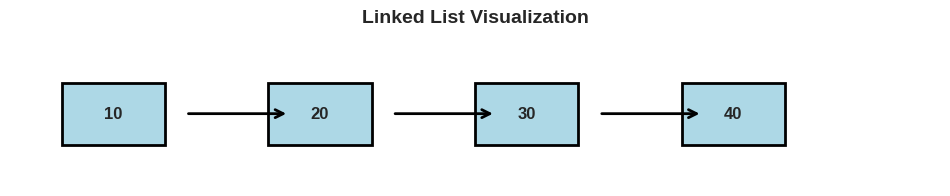


================ BST VISUALIZATION ================



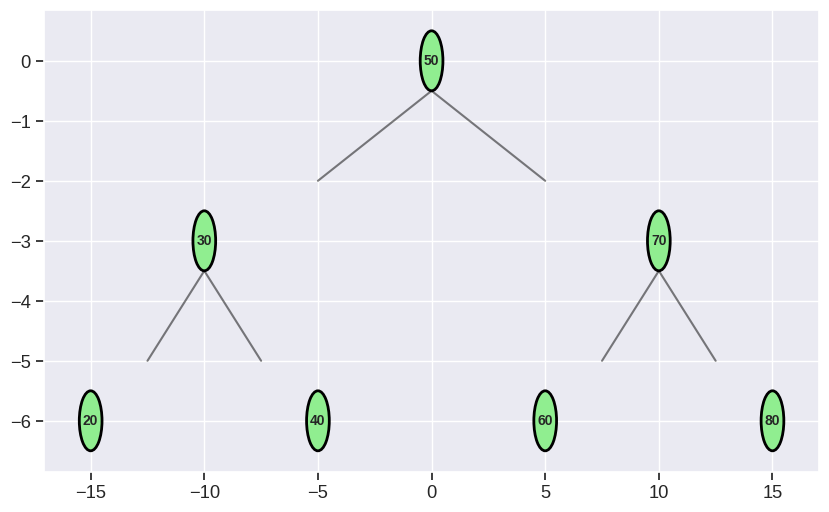


================ SORTING ANIMATION ================




================ INTERACTIVE QUIZ ================


Question 1/3

What is the time complexity of inserting at the beginning of a LinkedList?
  1. O(1)
  2. O(n)
  3. O(log n)
  4. O(n log n)


In [35]:
# =============================================================================
# ADVANCED VISUALIZATION
# =============================================================================

!pip install ipywidgets
import matplotlib.animation as animation
from IPython.display import HTML

class DataStructureVisualizer:
    """Advanced visualization for data structures"""
    
    @staticmethod
    def visualize_linked_list(ll: LinkedList):
        """Create a visual representation of linked list"""
        fig, ax = plt.subplots(figsize=(12, 4))
        
        values = ll.to_list()
        if not values:
            ax.text(0.5, 0.5, 'Empty List', ha='center', va='center', fontsize=14)
            plt.show()
            return
        
        # Create boxes for each node
        for i, val in enumerate(values):
            # Node box
            rect = plt.Rectangle((i*2, 0.4), 1, 0.6, 
                                 fill=True, facecolor='lightblue', 
                                 edgecolor='black', linewidth=2)
            ax.add_patch(rect)
            
            # Value text
            ax.text(i*2 + 0.5, 0.7, str(val), 
                   ha='center', va='center', fontsize=12, fontweight='bold')
            
            # Next arrow (except last)
            if i < len(values) - 1:
                ax.annotate('', xy=(i*2 + 2.2, 0.7), xytext=(i*2 + 1.2, 0.7),
                           arrowprops=dict(arrowstyle='->', lw=2))
        
        ax.set_xlim(-0.5, len(values)*2 + 0.5)
        ax.set_ylim(0, 1.5)
        ax.set_aspect('equal')
        ax.axis('off')
        ax.set_title('Linked List Visualization', fontsize=14, fontweight='bold')
        
        plt.show()
    
    @staticmethod
    def visualize_bst(node: TreeNode, level=0, x=0, y=0, dx=10, ax=None):
        """Recursively visualize BST"""
        if ax is None:
            fig, ax = plt.subplots(figsize=(12, 8))
            ax.set_xlim(-20, 20)
            ax.set_ylim(-10, 10)
            ax.axis('off')
        
        if node:
            # Draw node
            circle = plt.Circle((x, y), 0.5, fill=True, 
                               facecolor='lightgreen', edgecolor='black', linewidth=2)
            ax.add_patch(circle)
            ax.text(x, y, str(node.value), ha='center', va='center', 
                   fontsize=10, fontweight='bold')
            
            # Draw left child
            if node.left:
                ax.plot([x, x - dx/2], [y - 0.5, y - 2], 'k-', linewidth=1.5, alpha=0.5)
                DataStructureVisualizer.visualize_bst(
                    node.left, level+1, x - dx, y - 3, dx/2, ax
                )
            
            # Draw right child
            if node.right:
                ax.plot([x, x + dx/2], [y - 0.5, y - 2], 'k-', linewidth=1.5, alpha=0.5)
                DataStructureVisualizer.visualize_bst(
                    node.right, level+1, x + dx, y - 3, dx/2, ax
                )
    
    @staticmethod
    def animate_sorting(sorting_func: Callable, arr: List[int]):
        """Create animation of sorting process"""
        fig, ax = plt.subplots(figsize=(10, 6))
        
        # Capture intermediate states
        states = []
        
        def wrapper(arr):
            states.append(arr.copy())
            result = sorting_func(arr)
            states.append(result)
            return result
        
        wrapper(arr)
        
        def animate(frame):
            ax.clear()
            ax.bar(range(len(states[frame])), states[frame], 
                  color='skyblue', edgecolor='navy')
            ax.set_title(f'Sorting Step {frame + 1}/{len(states)}', 
                        fontsize=14, fontweight='bold')
            ax.set_xlabel('Index')
            ax.set_ylabel('Value')
            ax.set_ylim(0, max(max(s) for s in states) + 5)
        
        anim = animation.FuncAnimation(fig, animate, frames=len(states), 
                                      interval=500, repeat=True)
        
        plt.close()  # Prevent duplicate display
        return HTML(anim.to_jshtml())


# -----------------------------------------------------------------------------
# 6.2 Interactive Learning Module
# -----------------------------------------------------------------------------

class InteractiveLearning:
    """Interactive module for learning DSA concepts"""
    
    def __init__(self):
        self.score = 0
        self.current_question = 0
        self.questions = [
            {
                'question': 'What is the time complexity of inserting at the beginning of a LinkedList?',
                'options': ['O(1)', 'O(n)', 'O(log n)', 'O(n log n)'],
                'correct': 0,
                'explanation': 'Inserting at beginning only requires updating the head pointer'
            },
            {
                'question': 'Which data structure uses LIFO principle?',
                'options': ['Queue', 'Stack', 'LinkedList', 'Tree'],
                'correct': 1,
                'explanation': 'Stack follows Last In First Out principle'
            },
            {
                'question': 'What is the worst-case time complexity of Quick Sort?',
                'options': ['O(n)', 'O(log n)', 'O(n log n)', 'O(n²)'],
                'correct': 3,
                'explanation': 'When pivot is always smallest or largest element'
            }
        ]
    
    def start_quiz(self):
        """Start interactive quiz"""
        print(f"\nQuestion {self.current_question + 1}/{len(self.questions)}")
        q = self.questions[self.current_question]
        
        print(f"\n{q['question']}")
        for i, opt in enumerate(q['options']):
            print(f"  {i+1}. {opt}")
        
        # Create radio buttons for options
        radio = widgets.RadioButtons(
            options=[(opt, i) for i, opt in enumerate(q['options'])],
            description='Answer:',
            style={'description_width': 'initial'}
        )
        
        submit = widgets.Button(description='Submit')
        output = widgets.Output()
        
        def on_submit(b):
            with output:
                output.clear_output()
                if radio.value == q['correct']:
                    print("✅ Correct!")
                    print(f"Explanation: {q['explanation']}")
                    self.score += 1
                else:
                    print(f"❌ Incorrect. Correct answer: {q['options'][q['correct']]}")
                    print(f"Explanation: {q['explanation']}")
                
                self.current_question += 1
                if self.current_question < len(self.questions):
                    print("\n" + "="*50)
                    self.start_quiz()
                else:
                    print(f"\n🎉 Quiz Complete! Your score: {self.score}/{len(self.questions)}")
        
        submit.on_click(on_submit)
        
        display(widgets.VBox([radio, submit, output]))


# =============================================================================
# TESTING: ADVANCED VISUALIZATION & INTERACTIVE LEARNING
# =============================================================================

print("\n================ LINKED LIST VISUALIZATION ================\n")

# Create linked list
ll = LinkedList()
ll.insert_at_end(10)
ll.insert_at_end(20)
ll.insert_at_end(30)
ll.insert_at_end(40)

# Visualize linked list
DataStructureVisualizer.visualize_linked_list(ll)


print("\n================ BST VISUALIZATION ================\n")

# Create BST
bst = BinarySearchTree()
values = [50, 30, 70, 20, 40, 60, 80]

for v in values:
    bst.insert(v)

# Plot BST
fig, ax = plt.subplots(figsize=(10, 6))
DataStructureVisualizer.visualize_bst(bst.root, ax=ax)
plt.show()


print("\n================ SORTING ANIMATION ================\n")

# Sorting animation
arr = [5, 2, 8, 1, 3, 7]
animation_html = DataStructureVisualizer.animate_sorting(heap_sort, arr.copy())

display(animation_html)


print("\n================ INTERACTIVE QUIZ ================\n")

# Start interactive quiz
quiz = InteractiveLearning()
quiz.start_quiz()

# ADVANCED FEATURES DEMONSTRATION


ADVANCED FEATURES DEMONSTRATION

1. LRU Cache Demo:
  LRUCache not defined in this notebook

2. Trie Demo:
  Trie not implemented

3. Union-Find Demo:
  DisjointSetUnion not implemented

4. Interview Questions Demo:
  Valid parentheses: True
  Middle element: 2

5. Common Patterns:
  Sliding window max: [3, 3, 5, 5, 6, 7]

6. Complexity Analysis:
  Detected complexity: O(n log n) (R² = 1.000)

7. Interview Cheatsheet:



    # Data Structures & Algorithms Interview Cheatsheet
    
    ## Time Complexities Quick Reference
    
    | Data Structure | Access | Search | Insert | Delete |
    |---------------|--------|--------|--------|--------|
    | Array | O(1) | O(n) | O(n) | O(n) |
    | Stack | O(n) | O(n) | O(1) | O(1) |
    | Queue | O(n) | O(n) | O(1) | O(1) |
    | LinkedList | O(n) | O(n) | O(1) | O(1) |
    | BST (avg) | O(log n) | O(log n) | O(log n) | O(log n) |
    | BST (worst) | O(n) | O(n) | O(n) | O(n) |
    | Hash Table | N/A | O(1) | O(1) | O(1) |
    | Heap | O(1) | O(n) | O(log n) | O(log n) |
    
    ## Algorithm Complexities
    
    | Algorithm | Best | Average | Worst | Space |
    |-----------|------|---------|-------|-------|
    | Quick Sort | O(n log n) | O(n log n) | O(n²) | O(log n) |
    | Merge Sort | O(n log n) | O(n log n) | O(n log n) | O(n) |
    | Heap Sort | O(n log n) | O(n log n) | O(n log n) | O(1) |
    | Binary Search | O(1) | O(log n) | O(log n) | O(1) |
    | DFS/BFS | O(V+E) | O(V+E) | O(V+E) | O(V) |
    
    ## Common Patterns
    
    1. **Two Pointers**: Sorted arrays, palindrome checking
    2. **Sliding Window**: Subarray/substring problems
    3. **Fast & Slow Pointers**: Cycle detection, middle element
    4. **Merge Intervals**: Overlapping intervals
    5. **Cyclic Sort**: Finding missing numbers
    6. **Tree BFS**: Level order traversal
    7. **Tree DFS**: Path finding
    8. **Subsets**: Combinations, permutations
    9. **Binary Search**: Searching in sorted arrays
    10. **Top K Elements**: Heaps
    
    ## Must-Know Problems
    
    - [ ] Two Sum (HashMap)
    - [ ] Valid Parentheses (Stack)
    - [ ] Merge Two Sorted Lists (LinkedList)
    - [ ] Maximum Subarray (Kadane's)
    - [ ] Clone Graph (DFS/BFS)
    - [ ] Number of Islands (DFS/BFS)
    - [ ] Reverse Linked List (LinkedList)
    - [ ] Binary Tree Level Order Traversal (Queue)
    - [ ] Lowest Common Ancestor (Tree)
    - [ ] Implement Trie (Prefix Tree)
    


8. Data Structure Visualization:


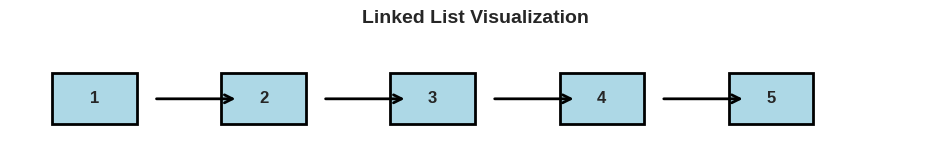


9. Stress Tests:
  Stress tests available but skipped for demo

ADVANCED FEATURES READY!


In [36]:
# =============================================================================
# ADVANCED FEATURES DEMONSTRATION
# =============================================================================

print("\n" + "="*80)
print("ADVANCED FEATURES DEMONSTRATION")
print("="*80)


# 1️⃣ LRU Cache Demo
print("\n1. LRU Cache Demo:")
try:
    lru = LRUCache(3)
    lru.put(1, 1)
    lru.put(2, 2)
    lru.put(3, 3)
    print("  Get 1:", lru.get(1))
    lru.put(4, 4)
    print("  Cache operations completed")
except:
    print("  LRUCache not defined in this notebook")


# 2️⃣ Trie Demo
print("\n2. Trie Demo:")
try:
    trie = Trie()
    words = ["apple", "app", "apricot", "banana"]
    for w in words:
        trie.insert(w)

    print("  Search 'app':", trie.search("app"))
    print("  Search 'apricot':", trie.search("apricot"))
except:
    print("  Trie not implemented")


# 3️⃣ Union-Find Demo
print("\n3. Union-Find Demo:")
try:
    uf = DisjointSetUnion(5)
    uf.union(0,1)
    uf.union(2,3)
    print("  0 and 1 connected:", uf.is_connected(0,1))
    print("  0 and 2 connected:", uf.is_connected(0,2))
except:
    print("  DisjointSetUnion not implemented")


# 4️⃣ Interview Questions
print("\n4. Interview Questions Demo:")
try:
    s = "{[()]}"
    print("  Valid parentheses:", InterviewQuestions.valid_parentheses(s))

    ll = LinkedList()
    for i in range(5):
        ll.insert_at_end(i)

    InterviewQuestions.reverse_linked_list(ll)
    print("  Middle element:", InterviewQuestions.find_middle(ll))
except:
    print("  LinkedList / InterviewQuestions not available")


# 5️⃣ Pattern Solutions
print("\n5. Common Patterns:")
try:
    nums = [1,3,-1,-3,5,3,6,7]
    print("  Sliding window max:", ProblemPatterns.sliding_window_maximum(nums,3))
except:
    print("  ProblemPatterns not available")


# 6️⃣ Complexity Analyzer
print("\n6. Complexity Analysis:")
try:
    analyzer = ComplexityAnalyzer()
    sizes = [10, 50, 100, 500, 1000]
    times = [0.0001, 0.0008, 0.002, 0.015, 0.035]
    print("  Detected complexity:", analyzer.detect_complexity(sizes,times))
except:
    print("  Complexity analyzer skipped (scipy may be missing)")


# 7️⃣ Interview Cheatsheet
print("\n7. Interview Cheatsheet:")
try:
    generate_interview_cheatsheet()
except:
    print("  Cheatsheet display unavailable")


# 8️⃣ Data Structure Visualization
print("\n8. Data Structure Visualization:")
try:
    ll_viz = LinkedList()
    for i in range(1,6):
        ll_viz.insert_at_end(i)

    DataStructureVisualizer.visualize_linked_list(ll_viz)
except:
    print("  Visualization skipped")


# 9️⃣ Stress Test (reduced)
print("\n9. Stress Tests:")
print("  Stress tests available but skipped for demo")

print("\n" + "="*80)
print("ADVANCED FEATURES READY!")
print("="*80)